# Begin

Two-level network.
1) first level network reconstructs observations via bottlenecking. It's goal is to learn structure of observation - represent it as a embedding vector
2) second level network predict next observations. It has temporal dimension. It spits out embeddings in terms of first level network and as such one could a) render predictions, b) use loss over embeddings

**Goal is to learn how to do predict in terms of embeddings**, not in terms of raw pixels. Predicting in terms of raw pixels is very slow and memory consuming, predicting in terms of embedding is fast. Our brain also doesn't predict in terms of pixels (visual).

We further strengthen model. `RenderHead` now consumes only embeddings from reconstruction model. For prediction model to render it pixels one must pass embeddings via translator. The justification is that embeddings from prediction model must be more abstract and hence lack of precise structural things. Otherwise prediction model must be extremly large: it must both keep structural components, derive more abstract components, move them around in a coherent stuff. Think of commute planning. We don't think in all nuances about where each step must be made but we think about commute in general terms. But when we execute commute in each moment we dive into concrete actions based on context of commute.

In [1]:
# @launchit.collected
# @launchit.collected_temp_config
# @launchit.collected_optuna
# @launchit.collected_initrd
# @launchit.collected_build_docker_launch

In [2]:
# @launchit.collected_manual_run_docker_launch
# @launchit.collected_optuna_run_docker_launch

In [3]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import gzip
import functools
import piq

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import ale_py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.nn.attention import SDPBackend, sdpa_kernel

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
import torch_utils
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement
import command_listener
import ob_preprocessor

# Init

In [4]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [5]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True, log_fname=os.path.join(project_root_path, 'run', subproject_name, notebook_name + '.log'))
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache_fname, artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache_fname=None, 
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        CONFIG = CONFIG._replace(artifact_registry_cache_fname=os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl'))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [6]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [7]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG.enable('file', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'baki',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18d_world_model_09',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18d_world_model_09.ipynb',
 'self_name': '18d_world_model_09',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18d_world_model_09.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [8]:
# @launchit.disable
# @launchit.collect
LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    launch_goal: str = None # train_encoder, train_predictor, train_all
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class General:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False
        is_torch_amp: bool = True

    @dataclass(slots=True)
    class Dataset:
        train: list = None # list of IDs of dataset used for training
        test: str = None # ID of a dataset used for test
        
    @dataclass(slots=True)
    class Model:
        parent: str = None # common parent for models
        input_sequence_length: int = 4
        actions_count: int = 6
        d_model: int = 256
        transformer: dict = None # params: layers_count, heads_count, attention_backend
        encoder: dict = None # params: is_trainable, ob_shape, vision_head, parent
        predictor: dict = None # params: is_trainable, parent, pred_latents_source
        renderer: dict = None # params: is_trainable, ob_shape, projector, render_engine, parent
        struct_projector: dict = None # params: is_trainable, d_inner, d_projected, parent

    @dataclass(slots=True)
    class Train:
        epochs_count: int = 1 
        batch_size: int = 32
        optimizer: str = 'AdamW'
        max_grad_norm: float = 1.0
        learn_rate: str = 'const(0.00025)'
        bce_loss_coef: str = 'const(1.0)'
        edge_loss_coef: str = 'const(1.0)'
        recon_loss_coef: str = 'const(1.0)'
        pred_loss: dict = None # params: type, loss_coef

    general: General = dataclasses.field(default_factory=General)
    dataset: Dataset = dataclasses.field(default_factory=Dataset)
    model: Model = dataclasses.field(default_factory=Model)
    train: Train = dataclasses.field(default_factory=Train)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.general = Hyperparameters.General(**hp.general)
        hp.dataset = Hyperparameters.Dataset(**hp.dataset)
        hp.model = Hyperparameters.Model(**hp.model)
        hp.train = Hyperparameters.Train(**hp.train)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Runtime

## Runtime

In [9]:
@dataclass(slots=True)
class Runtime:
    command_listener: object = None
    should_save_model: bool = True
    mp_ctx: object = None
    optuna_trial: dict = None
    artifact_registry_cache: dict = None
    artifact_registry: object = None
    summary_writer: object = None
    world_model: object = None
    dataset_module: object = None
    train_datasets: dict = None
    test_dataset_fname: str = None
    dataset_sequence_length: int = None
    render_test_batches: dict = None # recon, pred
    pov_coord_lists: object = None

## Configure

In [10]:
# @launchit.disable
# @launchit.collect
import random
HP.launch_goal = 'train_all'
HP.general.comment = None
HP.general.random_seed = random.randint(0, 100)
HP.general.is_torch_deterministic = True
HP.general.is_torch_compile = False
HP.general.is_torch_amp = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': 'train_all',
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 34,
             'is_torch_deterministic': True,
             'is_torch_compile': False,
             'is_torch_amp': True},
 'dataset': {'train': None, 'test': None},
 'model': {'parent': None,
           'input_sequence_length': 4,
           'actions_count': 6,
           'd_model': 256,
           'transformer': None,
           'encoder': None,
           'predictor': None,
           'renderer': None,
           'struct_projector': None},
 'train': {'epochs_count': 1,
           'batch_size': 32,
           'optimizer': 'AdamW',
           'max_grad_norm': 1.0,
           'learn_rate': 'const(0.00025)',
           'bce_loss_coef': 'const(1.0)',
           'edge_loss_coef': 'const(1.0)',
           'recon_loss_coef': 'const(1.0)',
           'pred_loss': None}}


## Create

In [11]:
assert type(CONFIG).__name__ == 'Config', 'Runtime should be created for full-fledged Config instance only'
LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)

RT = Runtime()
RT.command_listener = command_listener.CommandListener()

if 'COMMAND_LISTENER' in os.environ:
    RT.command_listener.start()
    LOG(f'CommandListener started on port={RT.command_listener.DEFAULT_PORT}')
    
RT.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

if HP.general.random_seed is not None:
    random.seed(HP.general.random_seed)
    torch.manual_seed(HP.general.random_seed)
    RNG = np.random.default_rng(HP.general.random_seed)    
    LOG(f'Random seed={HP.general.random_seed}')

if HP.general.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.general.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()

artifact_registry_type = os.environ.get('ARTIFACT_REGISTRY', '').upper()

if not artifact_registry_type:
    artifact_registry_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'NEXUS')

match artifact_registry_type:
    case 'NEXUS':
        kwargs = {}

        if os.environ.get('NEXUS_URL', None) is not None:
            kwargs['nexus_url'] = os.environ['NEXUS_URL']

        if os.environ.get('DOWNLOAD_NEXUS_URL', None) is not None:
            kwargs['download_nexus_url'] = os.environ['DOWNLOAD_NEXUS_URL']
        
        RT.artifact_registry = ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'ArtifactRegistry created')
    case 'S3':
        kwargs = {}
        artifact_registry_cache_fname = os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl')
        
        if os.path.exists(artifact_registry_cache_fname):
            with open(artifact_registry_cache_fname, 'rb') as f:
                RT.artifact_registry_cache = pickle.load(f)
                assert isinstance(RT.artifact_registry_cache, dict)
                LOG(f'Artifact registry cache loaded from "{artifact_registry_cache_fname}"')
        
            kwargs['cache'] = RT.artifact_registry_cache
        else:
            LOG(f'Artifact registry cache "{artifact_registry_cache_fname}" is absent, nothing to load')
        
        RT.artifact_registry = S3ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'S3ArtifactRegistry created')
    case _:
        assert False, f'Unsupported {artifact_registry_type=}'

if lc.version != 0:
    assert CONFIG.exec_mode != ExecMode.MASTER_NOTEBOOK, 'With MASTER_NOTEBOOK exec_mode one should not overwrite any of the launches (experiments)'
    RT.artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    meta = dict(
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)
else:
    assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK, 'MASTER_NOTEBOOK exec_mode is for working on 0 (dummy) version only'

RT.optuna_trial = None
optuna_trial_fname = os.path.join(CONFIG.initrd_path, 'optuna_trial.json')

if os.path.exists(optuna_trial_fname):
    with open(os.path.join(optuna_trial_fname), 'rt') as f:
        RT.optuna_trial = json.load(f)
        assert 'trial_number' in RT.optuna_trial, RT.optuna_trial
        assert 'study_serial' in RT.optuna_trial, RT.optuna_trial
        assert 'study_name' in RT.optuna_trial, RT.optuna_trial

    LOG(f'Optuna trial loaded from "{optuna_trial_fname}": {RT.optuna_trial}')

summary_log_dir = lc.name

if RT.optuna_trial is not None:
    summary_log_dir = os.path.join(summary_log_dir, f'opt_{RT.optuna_trial['study_serial']}')
    
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')

summary_writer_type = os.environ.get('SUMMARY_WRITER', '').upper()

if not summary_writer_type:
    summary_writer_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'RMQ')

match summary_writer_type:
    case 'RMQ':
        kwargs = {}

        if os.environ.get('RMQ_CONNECTION_URL', None) is not None:
            kwargs['rmq_connection_url'] = os.environ['RMQ_CONNECTION_URL']

        RT.summary_writer = RmqSummaryWriter(log_dir=summary_log_dir, **kwargs)
        LOG(f'RmqSummaryWriter created')
    case 'S3':
        RT.summary_writer = S3SummaryWriter(log_dir=summary_log_dir)
        LOG(f'S3SummaryWriter created')
    case _:
        assert False, f'Unsupported {summary_writer_type=}'

RT.summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 0)
RT.summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 0)
RT.summary_writer.flush()

Random seed=34
torch.backends.cudnn.deterministic=True
ArtifactRegistry created
Tensorboard run=18d_world_model_09/0
RmqSummaryWriter created


# Dataset

## Configure

In [12]:
# @launchit.disable
# @launchit.collect
HP.dataset.train = [
    '18b_dataset_02:8:cls=train,no=1,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=2,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=3,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=4,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=5,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=6,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=7,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=8,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=9,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=10,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=11,seq=8,mp=0,sh=3,210,160',
    # '18b_dataset_02:8:cls=train,no=12,seq=8,mp=0,sh=3,210,160',
]
HP.dataset.test = '18b_dataset_02:8:cls=test,no=1,seq=8,mp=0,sh=3,210,160'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': 'train_all',
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 34,
             'is_torch_deterministic': True,
             'is_torch_compile': False,
             'is_torch_amp': True},
 'dataset': {'train': ['18b_dataset_02:8:cls=train,no=1,seq=8,mp=0,sh=3,210,160'],
             'test': '18b_dataset_02:8:cls=test,no=1,seq=8,mp=0,sh=3,210,160'},
 'model': {'parent': None,
           'input_sequence_length': 4,
           'actions_count': 6,
           'd_model': 256,
           'transformer': None,
           'encoder': None,
           'predictor': None,
           'renderer': None,
           'struct_projector': None},
 'train': {'epochs_count': 1,
           'batch_size': 32,
           'optimizer': 'AdamW',
           'max_grad_norm': 1.0,
           'learn_rate': 'const(0.00025)',
           'bce_loss_coef': 'const(1.0)',
           'edge_loss_coef': 'const(1.0)',
           'recon_loss_coef': 'const(1.0)',
           'pred_loss': None}}

## Create

In [13]:
DATASET_NOTEBOOK_FNAME = '18b_dataset_02.ipynb'
source_code = launchit.extract_source_code(DATASET_NOTEBOOK_FNAME, collect_inds=[None, 'export_dataset'])
RT.dataset_module = lu.make_module(f'dataset_notebook', source_code)
RT.dataset_module.CONFIG = CONFIG
RT.dataset_module.RNG = RNG
RT.dataset_module.LOG = LOG
sys.modules['__main__'].Dataset = RT.dataset_module.Dataset # Req-d for unpickling

In [14]:
def download_dataset(dataset_id):
    coords = hp_parse_artifact_source(dataset_id)
    classifier_suffix = lu.when(coords.asset_classifier, lambda: '.' + coords.asset_classifier, '')
    downloaded_pkl_gz_fname = os.path.join(CONFIG.private_data_path, f'{coords.model_name}.{coords.model_version}{classifier_suffix}.pkl.gz')
    
    if not os.path.exists(downloaded_pkl_gz_fname):
        pkl_gz = RT.artifact_registry.get_asset_content(
            coords.model_name, 
            coords.model_version, 
            asset_ext='gz', 
            asset_classifier=coords.asset_classifier, 
            maven_group_id=coords.group_id,
        )

        with open(downloaded_pkl_gz_fname, 'wb') as f:
            f.write(pkl_gz)
            LOG(f'"{dataset_id}" saved to "{downloaded_pkl_gz_fname}"')
    else:
        LOG(f'"{dataset_id}" is backed by "{downloaded_pkl_gz_fname}"')

    return downloaded_pkl_gz_fname

@functools.lru_cache(maxsize=None)
def load_dataset(fname):
    with gzip.GzipFile(filename=fname, mode='rb') as gzip_file:
        dataset = pickle.load(gzip_file)
        assert dataset.obs.shape[-3:] == (3, 210, 160), f'Unsupported {dataset.obs.shape[-3:]=}'
        return dataset

In [15]:
RT.train_datasets = {}
RT.dataset_sequence_length = None

for train_dataset_id in HP.dataset.train:
    fname = download_dataset(train_dataset_id)
    dataset = load_dataset(fname)

    if RT.dataset_sequence_length is None:
        RT.dataset_sequence_length = dataset.sequence_length
    else:
        assert dataset.sequence_length == RT.dataset_sequence_length
    
    RT.train_datasets[train_dataset_id] = fname

"18b_dataset_02:8:cls=train,no=1,seq=8,mp=0,sh=3,210,160" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/18b_dataset_02.8.train,no=1,seq=8,mp=0,sh=3,210,160.pkl.gz"


In [16]:
RT.test_dataset_fname = download_dataset(HP.dataset.test)
test_dataset = load_dataset(RT.test_dataset_fname)

"18b_dataset_02:8:cls=test,no=1,seq=8,mp=0,sh=3,210,160" is backed by "/home/misha/dev/mine/neurolab/data/18_rl/18b_dataset_02.8.test,no=1,seq=8,mp=0,sh=3,210,160.pkl.gz"


# WorldModel

In [17]:
# @launchit.collect_export
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
from torch.nn.attention import SDPBackend, sdpa_kernel

## Projectors

### LinearProjector

In [18]:
# @launchit.collect_export
class LinearProjector(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        d_model: int = 256
        d_projected: int = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.linear = nn.Linear(params.d_model, params.d_projected)

    ForwardResult = namedtuple('ForwardResult', 'y, reg_losses')

    def forward(self, x):
        return self.ForwardResult(y=self.linear(x), reg_losses={})

### MLPProjector

In [19]:
class MLPProjector(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        d_model: int = 256
        d_inner: int = 128
        d_projected: int = 256
    
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.net = nn.Sequential(
            nn.Linear(self.params.d_model, self.params.d_inner),
            nn.LayerNorm(self.params.d_inner),
            nn.ReLU(),
            nn.Linear(self.params.d_inner, self.params.d_projected)
        )
        
    def forward(self, x):
        return self.net(x)

### DreamerProjector

In [20]:
# @launchit.collect_export
class DreamerProjector(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        d_model: int = 256
        groups_count: int = 32
        classes_count: int = 8
        d_projected: int = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.internal_dims_count = self.params.groups_count * self.params.classes_count
        self.logits_maker = nn.Linear(self.params.d_model, self.internal_dims_count)
        self.out_maker = nn.Linear(self.internal_dims_count, self.params.d_projected)

    ForwardResult = namedtuple('ForwardResult', 'y, reg_losses')

    def forward(self, x, temperature=1.0):
        x_shape = x.shape
        logits = self.logits_maker(x) # (..., d_projected)
        logits = logits.view(*x.shape[:-1], self.params.groups_count, self.params.classes_count) # (..., groups, classes)
        reg_losses = {}

        if self.training:
            # KL-loss versus uniform distr
            probs = F.softmax(logits, dim=-1)
            reg_losses['DreamerProjector.kl_loss'] = probs * (torch.log(probs + 1e-8) - torch.log(torch.tensor(1.0 / self.params.classes_count)))
            
            # Gumbel-Softmax allows gradients to flow through discrete sampling
            # hard=True forces the forward pass to be strict 1s and 0s (one-hot)
            latents = F.gumbel_softmax(logits, tau=temperature, hard=True, dim=-1)
        else:
            # Test time: just take the most likely category (argmax)
            indices = logits.argmax(dim=-1)
            latents = F.one_hot(indices, num_classes=self.params.classes_count).float()
            
        latents = latents.view(*x.shape[:-1], self.internal_dims_count) # (..., internal_dims_count)
        return self.ForwardResult(
            y=self.out_maker(latents), # (..., d_projected)
            reg_losses=reg_losses,
        )       

## VisionHead

In [21]:
# @launchit.collect_export
class VisionHead(nn.Module):
    @dataclass(slots=True)
    class Params:
        input_shape: tuple = (1, 178, 152)
        grid: tuple = None # output features grid
        features_counts: tuple = None # how many output features per CNN layer
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.params.input_shape = tuple(params.input_shape)
        self.params.grid = tuple(params.grid)
        self.params.features_counts = tuple(params.features_counts)

        if self.params.input_shape == (1, 178, 152) or self.params.input_shape == (1, 178, 178):
            assert len(self.params.features_counts) == 4, len(self.params.features_counts)

            if self.params.grid == (6, 6):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (7, 7):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (9, 9):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    # Layer 2: 87x74 -> 42x35
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=1, padding=0),  # -> (fc[3], 18, 15)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
        elif self.params.input_shape == (3, 89, 76):
            assert self.params.grid == (7, 6), f'Unsupported {self.params.grid=}'
            fcs = self.params.features_counts
            self.cnn = nn.Sequential(
                nn.Conv2d(3, fcs[0], kernel_size=3, stride=2, padding=(0, 1)),  # -> (fcs[0], 44, 38)
                nn.BatchNorm2d(fcs[0]),
                nn.ReLU(),
            
                nn.Conv2d(fcs[0], fcs[1], kernel_size=3, stride=2, padding=1), # -> (fcs[1], 22, 19)
                nn.BatchNorm2d(fcs[1]),
                nn.ReLU(),
            
                nn.Conv2d(fcs[1], fcs[2], kernel_size=4, stride=3, padding=1), # -> (fcs[2], 7, 6)
                nn.BatchNorm2d(fcs[2]),
                nn.ReLU(),
            )
        elif self.params.input_shape == (1, 45, 45) and self.params.grid == (5, 5):
            assert len(self.params.features_counts) == 3, len(self.params.features_counts)
            self.cnn = nn.Sequential(
                nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 21, 21), detect raw edges/shapes
                nn.BatchNorm2d(self.params.features_counts[0]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 9, 9), detect mid-level motion paths
                nn.BatchNorm2d(self.params.features_counts[1]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=5, stride=1, padding=0), # -> (fc[2], 5, 5), shape extraction
                nn.ReLU(),
            )
        else:
            assert False, f'Unsupported {params.input_shape=}'

        self.out_tokens_count = math.prod(self.params.grid)
        self.out_features_count = self.params.features_counts[-1]

    def forward(self, x):
        x_shape = x.shape
        x = x.view(-1, *x.shape[-3:]) # (uberbatch, color, height, width)
        features = self.cnn(x) # (uberbatch, out_features_count, grid[0], grid[1]) 
        return features.view(*x_shape[:-3], self.out_features_count, *self.params.grid)

## RenderHead

In [22]:
# @launchit.collect_export
class RenderHead(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        ob_shape: tuple = (1, 178, 152)
        d_model: int = 256
        projector: dict = None
        render_engine: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.ob_shape == (1, 178, 152), f'Unsupported {self.params.ob_shape=}'

        match self.params.render_engine['type']:
            case 'layer': self.create_layer_render_engine()
            case 'block': self.create_block_render_engine()
            case _: assert False, f'Unsupported {self.params.render_engine['type']=}'    

        if self.params.projector['type'] == 'linear':
            projector_params = DreamerProjector.Params(
                d_model=self.params.d_model,
                d_projected=math.prod(self.subrenderer_input_shape),
            )
            self.projectors = nn.ModuleList([
                LinearProjector(projector_params) for _ in range(len(self.subrenderers))
            ])
        elif self.params.projector['type'] == 'dreamer':
            projector_params = DreamerProjector.Params(
                d_model=self.params.d_model,
                groups_count=self.params.projector['groups_count'],
                classes_count=self.params.projector['classes_count'],
                d_projected=math.prod(self.subrenderer_input_shape),
            )
            self.projectors = nn.ModuleList([
                DreamerProjector(projector_params) for _ in range(len(self.subrenderers))
            ])
        else:
            assert False, f'Unsupported {self.params.projector=}'

        assert len(self.subrenderers) == len(self.projectors)

    def forward(self, latents):
        # latents must contain all data sufficient to render observation
        # latents.shape = (..., d_model)
        assert latents.shape[-1] == self.params.d_model
        
        if self.params.render_engine['type'] == 'layer':
            return self.layer_forward(latents)
        elif self.params.render_engine['type'] == 'block':
            return self.block_forward(latents)
        else:
            assert False, f'Unsupported {self.params.render_engine['type']=}'

    LayerForwardResult = namedtuple('LayerForwardResult', 'logits, contents, gates, alpha_masks, reg_losses')
    BlockForwardResult = namedtuple('BlockForwardResult', 'logits, reg_losses')
    
    def layer_forward(self, latents):
        latents_shape = latents.shape
        latents = latents.reshape(-1, self.params.d_model) # (uberbatch, d_model)
        uberbatch_size = len(latents)
        contents = []
        gates = []
        reg_losses = {}
        
        # 1. Run the latent code through every subrenderer (expert)
        for projector, subrenderer in zip(self.projectors, self.subrenderers):
            projs = projector(latents) # (uberbatch, *subrenderer_input_shape)
            
            for k, v in projs.reg_losses.items():
                k = 'RenderHead.' + k
                l = lu.coalesce_fn(reg_losses.get(k, None), lambda x: [x], [])
                reg_losses[k] = torch.cat(l + [v], dim=0)

            features = projs.y
            features = features.view(uberbatch_size, *self.subrenderer_input_shape)
            out = subrenderer(features) 
            out = out.view(uberbatch_size, 2, *self.params.ob_shape)
            contents.append(out[:,0:1]) # Proposed pixel intensities, (uberbatch, 1, *self.params.ob_shape)
            gates.append(out[:,1:2])    # Proposed selection urgency, (uberbatch, 1, *self.params.ob_shape)

        for k, v in reg_losses.items():
            reg_losses[k] = reg_losses[k].sum(dim=-1).mean()

        contents = torch.cat(contents, dim=1) # (uberbatch, subrenderers, *self.params.ob_shape)
        gates = torch.cat(gates, dim=1) # (uberbatch, subrenderers, *self.params.ob_shape)
        assert contents.shape == (uberbatch_size, len(self.subrenderers), *self.params.ob_shape), contents.shape
        assert gates.shape == contents.shape
        
        # 2. Compute Softmax-Gated Alpha Masks across the Layer Dimension
        # This mathematically forces the masks for every single pixel to sum to 1.0.
        # It creates a clean, fully differentiable competitive gate.
        alpha_masks = F.softmax(gates, dim=2)

        # 3. Blending Step: Element-wise multiply content by alpha, then sum across layers
        # This is a fully differentiable weighted average per pixel
        # Note: return raw logits since AMP requires BCEWithLogitsLoss which requires raw logits
        logits = torch.sum(contents * alpha_masks, dim=1) # (uberbatch, 1, *self.params.ob_shape)
        logits_output_shape = (*latents_shape[:-1], *self.params.ob_shape)
        other_output_shape = (*latents_shape[:-1], len(self.subrenderers), *self.params.ob_shape)
        return self.LayerForwardResult(
            logits=logits.view(logits_output_shape), 
            contents=contents.view(other_output_shape), 
            gates=gates.view(other_output_shape), 
            alpha_masks=alpha_masks.view(other_output_shape),
            reg_losses=reg_losses,
        )

    def block_forward(self, latents):
        latents_shape = latents.shape
        latents = latents.reshape(-1, self.params.d_model) # (uberbatch, d_model)
        uberbatch_size = len(latents)
        reg_losses = {}
        interim_canvases = torch.zeros(uberbatch_size, 1, *self.interim_canvas_shape, device=latents.device)
        
        for projector, subrenderer, landing in zip(self.projectors, self.subrenderers, self.subrenderer_landings):
            projs = projector(latents) # (uberbatch, *subrenderer_input_shape)
            
            for k, v in projs.reg_losses.items():
                k = 'RenderHead.' + k
                l = lu.coalesce_fn(reg_losses.get(k, None), lambda x: [x], [])
                reg_losses[k] = torch.cat(l + [v], dim=0)

            features = projs.y
            features = features.view(uberbatch_size, *self.subrenderer_input_shape)
            block = subrenderer(features) # (uberbatch, *subrenderer_output_shape)
            _, _, block_h, block_w = block.shape
            interim_canvases[:,:,landing[0]:landing[0]+block_h,landing[1]:landing[1]+block_w] = block

        for k, v in reg_losses.items():
            reg_losses[k] = reg_losses[k].sum(dim=-1).mean()

        hw_shape = self.params.ob_shape[1:] # (1, 178, 152) -> (178, 152)
        logits = VF.center_crop(interim_canvases, hw_shape)
        logits_output_shape = (*latents_shape[:-1], *self.params.ob_shape)
        return self.BlockForwardResult(
            logits=logits.view(logits_output_shape), 
            reg_losses=reg_losses,
        )
        
    def create_layer_render_engine(self):
        fcs = self.params.render_engine.get('features_counts', (64, 48, 32, 16))
        is_batch_norm = self.params.render_engine.get('is_batch_norm', False)
        self.subrenderer_input_shape = (fcs[0], 11, 9)
        subrenderer = lambda: nn.Sequential(
            nn.ConvTranspose2d(fcs[0], fcs[1], kernel_size=4, stride=2, padding=1, output_padding=(0, 1)), # -> (48, 22, 19)
            lu.when(is_batch_norm, lambda: nn.BatchNorm2d(fcs[1]), lambda: nn.Identity()),
            nn.ReLU(),
            
            nn.ConvTranspose2d(fcs[1], fcs[2], kernel_size=4, stride=2, padding=1), # -> (32, 44, 38)
            lu.when(is_batch_norm, lambda: nn.BatchNorm2d(fcs[2]), lambda: nn.Identity()),
            nn.ReLU(),
            
            nn.ConvTranspose2d(fcs[2], fcs[3], kernel_size=4, stride=2, padding=1, output_padding=(1, 0)), # -> (16, 89, 76)
            lu.when(is_batch_norm, lambda: nn.BatchNorm2d(fcs[3]), lambda: nn.Identity()),
            nn.ReLU(),
            
            nn.ConvTranspose2d(fcs[3], 2, kernel_size=4, stride=2, padding=1), # -> (2, 178, 152) # pixel importance (gate) + pixel instensity (content)
            # no nn.Sigmoid here because of AMP and BCELoss. AMP forces to uses BCEWithLogitsLoss
        )
        self.subrenderers = nn.ModuleList([
            subrenderer() for _ in range(self.params.render_engine['layers_count'])
        ]) 

    def create_block_render_engine(self):
        block_layout = tuple(self.params.render_engine['layout'])
        is_batch_norm = self.params.render_engine.get('is_batch_norm', False)
        
        if block_layout == (2, 2):
            self.subrenderer_input_shape = (64, 6, 5)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # (6, 5) -> (12, 10)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(32), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # (12, 10) -> (24, 20)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(16), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=(4, 2), stride=(4, 4), padding=2), # (24, 20) -> (92, 74) 
            )
            block_output_shape = (92, 74)
        elif block_layout == (3, 3):
            self.subrenderer_input_shape = (48, 4, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=0), # (4, 3) -> (10, 8)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(32), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=0), # (10, 8) -> (22, 18)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(16), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=3, stride=3, padding=1), # (22, 18) -> (64, 52)
            )
            block_output_shape = (64, 52)
        elif block_layout == (4, 3):
            self.subrenderer_input_shape = (48, 3, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=0), # (3, 3) -> (8, 8)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(32), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=0), # (8, 8) -> (18, 18)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(16), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1, kernel_size=(14, 3), stride=(2, 3), padding=1), # (18, 18) -> (46, 52)
            )
            block_output_shape = (46, 52)
        elif block_layout == (5, 5):
            self.subrenderer_input_shape = (48, 3, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=1), # (3, 3) -> (6, 6)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(32), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # (6, 6) -> (12, 12)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(16), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1,  kernel_size=6, stride=3, padding=(1, 1)), # (12, 12) -> (37, 37)
            )
            block_output_shape = (37, 37)
        elif block_layout == (6, 6):
            self.subrenderer_input_shape = (32, 3, 3)
            subrenderer = lambda: nn.Sequential(
                nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1), # (3, 3) -> (6, 6)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(32), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # (6, 6) -> (12, 12)
                lu.when(is_batch_norm, lambda: nn.BatchNorm2d(16), lambda: nn.Identity()),
                nn.ReLU(),
                
                nn.ConvTranspose2d(16, 1,  kernel_size=(3,8), stride=(3,2), padding=(1, 1)), # (12, 12) -> (34, 28)
            )
            block_output_shape = (34, 28)
        else:
            assert False, f'Unsupported {block_layout=}'

        blocks_count = math.prod(block_layout)
        self.subrenderers = nn.ModuleList([subrenderer() for _ in range(blocks_count)])
        self.interim_canvas_shape = (block_output_shape[0] * block_layout[0], block_output_shape[1] * block_layout[1])
        self.subrenderer_landings = []
        
        for i in range(block_layout[0]):
            for j in range(block_layout[1]):
                land_i = block_output_shape[0] * i
                land_j = block_output_shape[1] * j
                self.subrenderer_landings.append((land_i, land_j))

### Test

In [23]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
t.projector_variants = [
    dict(type='linear'),
    dict(type='dreamer', groups_count=32, classes_count=8),
]
t.render_engine_variants = [
    dict(type='layer', layers_count=4),
    dict(type='block', layout=(2, 2)),
    dict(type='block', layout=(3, 3)),
    dict(type='block', layout=(4, 3)),
    dict(type='block', layout=(5, 5)),
    dict(type='block', layout=(6, 6)),
]

for t.projector in t.projector_variants:
    for t.render_engine in t.render_engine_variants:
        print(f'{t.projector=}, {t.render_engine=}')
        t.params = RenderHead.Params(
            ob_shape=(1, 178, 152),
            d_model=256,
            projector=t.projector,
            render_engine=t.render_engine,
        )
        t.model = RenderHead(t.params).to(t.device)
        print(t.model)
        t.params_count = sum(p.numel() for p in t.model.parameters())
        print(f'{t.params_count=:_}')
        
        t.envs_count = 2
        t.sequence_length = 4
        t.embs = torch.zeros(t.envs_count, t.sequence_length, t.params.d_model).to(t.device)
        print(f'{t.embs.shape=}')
        
        t.fr = t.model(t.embs)
        print(f'{t.fr.logits.shape=}')
        print(f'{t.fr.reg_losses=}')
        print('')

t.projector={'type': 'linear'}, t.render_engine={'type': 'layer', 'layers_count': 4}
RenderHead(
  (subrenderers): ModuleList(
    (0-3): 4 x Sequential(
      (0): ConvTranspose2d(64, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(0, 1))
      (1): Identity()
      (2): ReLU()
      (3): ConvTranspose2d(48, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): Identity()
      (5): ReLU()
      (6): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 0))
      (7): Identity()
      (8): ReLU()
      (9): ConvTranspose2d(16, 2, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    )
  )
  (projectors): ModuleList(
    (0-3): 4 x LinearProjector(
      (linear): Linear(in_features=256, out_features=6336, bias=True)
    )
  )
)
t.params_count=6_843_528
t.embs.shape=torch.Size([2, 4, 256])
t.fr.logits.shape=torch.Size([2, 4, 1, 178, 152])
t.fr.reg_losses={}

t.projector={'type': 'linear'}, t.render_engine={'typ

## Encoder

In [24]:
# @launchit.collect_export
class Encoder(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        ob_shape: tuple = (1, 178, 152)
        d_model: int = None
        vision_head: dict = None
        transformer: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert isinstance(self.params.ob_shape, (tuple, list)), self.params.ob_shape
        self.params.ob_shape = tuple(params.ob_shape)

        assert self.params.vision_head is not None
        vision_head_params = VisionHead.Params(
            input_shape=self.params.ob_shape,
            grid=self.params.vision_head['grid'],
            features_counts=self.params.vision_head['features_counts'],
        )
        self.vision_head = VisionHead(vision_head_params)
        self.tokens_per_ob = self.vision_head.out_tokens_count
        self.ingress_projector = nn.Linear(self.vision_head.out_features_count, self.params.d_model)
        self.ingress_normalizer = nn.LayerNorm(self.params.d_model)
        self.i_spatial_encoding = nn.Parameter(torch.randn(1, self.vision_head.params.grid[0], 1, self.params.d_model))
        self.j_spatial_encoding = nn.Parameter(torch.randn(1, 1, self.vision_head.params.grid[1], self.params.d_model))
        self.latent_encoding = nn.Parameter(torch.randn(1, 1, self.params.d_model)) 
        self.latents_count = 1
        self.internal_sequence_length = self.tokens_per_ob + self.latents_count

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 256 * 4 = 2048
            nhead=self.params.transformer['heads_count'], 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        attention_backend_names = lu.when(
            isinstance(self.params.transformer['attention_backend'], str), 
            [self.params.transformer['attention_backend']], 
            self.params.transformer['attention_backend'],
        )
        self.attention_backend = list(map(lambda x: getattr(SDPBackend, x), attention_backend_names))
        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.transformer['layers_count'],
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
            norm=nn.LayerNorm(self.params.d_model), # output normalizer
        )

    @property
    def grad_norm_groups(self):
        groups = dict(
            vision_head=list(self.vision_head.parameters()),
            ingress_projector=list(self.ingress_projector.parameters()),
            spatial_encoding=[self.i_spatial_encoding, self.j_spatial_encoding],
            latent_encoding=[self.latent_encoding],
            transformer=list(self.transformer.parameters()),
        )

        return groups
        
    def train(self, mode=True):
        # DO NOT call super().train(mode)!!!
        # This is due to issues with strange transformer behavior when: eval mode + torch.no_grad() + attention_mask.
        # See: https://share.google/aimode/lFz0O2Qgduhc185Zt
        self.vision_head.train(mode and self.is_trainable)

    ForwardResult = namedtuple('ForwardResult', 'latents')

    def forward(self, obs):
        # obs.shape = (..., color, height, width)
        obs_shape = obs.shape
        obs = obs.view(-1, *obs.shape[-3:]) # (uberbatch, color, height, width)
        uberbatch_size = len(obs)

        # EMBED input data
        x = self.embed_input_data(obs) # (uberbatch, tokens, d_model)
        assert x.shape == (uberbatch_size, self.tokens_per_ob, self.params.d_model), x.shape

        # ATTACH latent to x
        latents = self.latent_encoding.expand(uberbatch_size, 1, -1)
        x = torch.cat([x, latents], dim=1) 
        assert x.shape == (uberbatch_size, self.internal_sequence_length, self.params.d_model), x.shape
        
        # TRANSFORM: information from ob_tokens is to be extracted into latents
        with sdpa_kernel(self.attention_backend):
            y = self.transformer(
                x, 
                is_causal=False,
            )

        # GET latents - they must contain information sufficient to reconstruct obs
        y = y[:,-1]
        target_shape = (*obs_shape[:-3], self.params.d_model)
        y = y.view(target_shape)
        return self.ForwardResult(latents=y)

    def embed_input_data(self, obs):
        # obs.shape = (..., color, height, width)
        assert obs.shape[-3:] == self.vision_head.params.input_shape, (obs.shape[-3:], self.vision_head.params.input_shape)
        obs_shape = obs.shape
        obs = obs.view(-1, *obs.shape[-3:])
        uberbatch_size = len(obs)

        if obs.dtype == torch.uint8:
            obs = obs / 255.0
        else:
            assert torch.all((0 <= obs) & (obs <= 1.0))

        features = self.vision_head(obs)
        assert features.shape == (uberbatch_size, self.vision_head.out_features_count, self.vision_head.params.grid[0], self.vision_head.params.grid[1]) 
        
        # Turn visual features into embeddings (ob_tokens)
        features = features.permute(0, 2, 3, 1)
        assert features.shape == (uberbatch_size, self.vision_head.params.grid[0], self.vision_head.params.grid[1], self.vision_head.out_features_count) 
        embs = self.ingress_projector(features)
        assert embs.shape == (uberbatch_size, self.vision_head.params.grid[0], self.vision_head.params.grid[1], self.params.d_model) 
        embs = self.ingress_normalizer(embs)

        # Mark ob tokens with location (spatial) 
        embs += self.i_spatial_encoding
        embs += self.j_spatial_encoding

        target_shape = (*obs_shape[:-3], self.tokens_per_ob, self.params.d_model)
        return embs.view(target_shape)

## Predictor

In [25]:
# @launchit.collect_export
class Predictor(torch_utils.TrainableModule):
    @dataclass(slots=True)
    class Params:
        input_sequence_length: int = None
        pred_sequence_length: int = None
        pred_latents_source: str = None
        actions_count: int = None
        d_model: int = None
        transformer: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.actions_count > 0
        assert self.params.input_sequence_length > 0
        assert self.params.pred_sequence_length > 0

        self.temporal_encoding = nn.Parameter(torch.randn(1, self.params.input_sequence_length + self.params.pred_sequence_length, self.params.d_model))
        self.action_sequence_length = self.params.input_sequence_length + self.params.pred_sequence_length
        self.action_encoding = nn.Embedding(self.params.actions_count, self.params.d_model)
        self.pred_latent_encoding = nn.Parameter(torch.randn(1, self.params.pred_sequence_length, self.params.d_model))

        if self.params.pred_latents_source == 'actions':
            self.internal_sequence_length = (
                self.params.input_sequence_length +  # input latents
                (self.params.input_sequence_length + self.params.pred_sequence_length) # all actions
            )
        elif self.params.pred_latents_source == 'separate':
            self.internal_sequence_length = (
                self.params.input_sequence_length +  # input latents
                (self.params.input_sequence_length + self.params.pred_sequence_length) + # all actions
                self.params.pred_sequence_length # separate pred_latents
            )
        else:
            assert False, f'Unsupported {self.params.pred_latents_source=}'

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 256 * 4 = 2048
            nhead=self.params.transformer['heads_count'], 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        self.register_buffer('attention_mask', self.generate_attention_mask())
        
        attention_backend_names = lu.when(
            isinstance(self.params.transformer['attention_backend'], str), 
            [self.params.transformer['attention_backend']], 
            self.params.transformer['attention_backend'],
        )
        self.attention_backend = list(map(lambda x: getattr(SDPBackend, x), attention_backend_names))
        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.transformer['layers_count'],
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
            norm=nn.LayerNorm(self.params.d_model), # output normalizer
        )

    @property
    def grad_norm_groups(self):
        groups = dict(
            temporal_encoding=[self.temporal_encoding],
            action_encoding=[self.action_encoding],
            pred_latent_encoding=[self.pred_latent_encoding],
            transformer=list(self.transformer.parameters()),
        )

        return groups
        
    def train(self, mode=True):
        # DO NOT call super().train(mode)!!!
        # This is due to issues with strange transformer behavior when: eval mode + torch.no_grad() + attention_mask.
        # See: https://share.google/aimode/lFz0O2Qgduhc185Zt
        pass

    ForwardResult = namedtuple('ForwardResult', 'latents')

    def forward(self, latents, padding_masks, actions):
        batch_size = len(latents)
        assert latents.shape == (batch_size, self.params.input_sequence_length, self.params.d_model)
        assert padding_masks.shape == (batch_size, self.params.input_sequence_length)
        assert actions.shape == (batch_size, self.action_sequence_length)

        input_temporal_encoding = self.temporal_encoding[0,:self.params.input_sequence_length]
        latents += input_temporal_encoding

        action_latents = self.action_encoding(actions)
        assert action_latents.shape == (batch_size, self.action_sequence_length, self.params.d_model)
        action_latents += self.temporal_encoding

        if self.params.pred_latents_source == 'actions':
            # ATTACH actions latents to input latents (state/structure latents)
            # action latents would eventually morph to predictive latents
            x = torch.cat([latents, action_latents], dim=1)
        elif self.params.pred_latents_source == 'separate':
            # ATTACH action latents and separate predictive latents to  input latents (state/structure latents)
            pred_temporal_encoding = self.temporal_encoding[0,-self.params.pred_sequence_length:]
            pred_latents = self.pred_latent_encoding.expand(batch_size, -1, -1) + pred_temporal_encoding
            x = torch.cat([latents, action_latents, pred_latents], dim=1)
        else:
            assert False, f'Unsupported {self.params.pred_latents_source=}'

        assert x.shape == (batch_size, self.internal_sequence_length, self.params.d_model), x.shape
        pred_latents_count = self.internal_sequence_length - self.params.input_sequence_length
        # ALIGN padding masks with x
        # pred_latents are not pad masked so add zeros to padding_masks
        padding_masks = torch.cat([padding_masks, torch.zeros(batch_size, pred_latents_count, dtype=padding_masks.dtype, device=padding_masks.device)], dim=1)
        assert padding_masks.shape == (batch_size, self.internal_sequence_length), padding_masks.shape
        
        # TRANSFORM
        with sdpa_kernel(self.attention_backend):
            y = self.transformer(
                x, 
                src_key_padding_mask=padding_masks,
                # mask=self.attention_mask, 
                is_causal=False, # not an ordinary causal mask
            )

        # RESULT is fetched from pred_latents
        y = y[:,-self.params.pred_sequence_length:]
        return self.ForwardResult(latents=y)

    def generate_attention_mask(self):
        return torch.zeros(self.internal_sequence_length, self.internal_sequence_length)
        
        # Blank slate matrix to put attention mask components in
        am = torch.zeros(self.internal_sequence_length, self.internal_sequence_length)

        # Ordinary causal mask for input latents
        input_latents_am = nn.Transformer.generate_square_subsequent_mask(self.params.sequence_length)
        input_latents_am = torch.where(torch.isinf(input_latents_am), 0, 1)
        am[:len(input_latents_am),:len(input_latents_am)] = input_latents_am # top-left square

        # Pred latents could attend to themselves
        am[len(input_latents_am):,len(input_latents_am):] = torch.eye(self.params.pred_latents_count) # bottom-right square
        
        # Pred latents independently could attend to all input latents
        am[len(input_latents_am):,:len(input_latents_am)] = 1 # bottom-left rect
        assert torch.all(am[:len(input_latents_am),len(input_latents_am):] == 0), 'Input latents should not attend any pred latents'
        return torch.where(am == 0, -torch.inf, 0) # nn.TransformerEncoder expects: 0 - could attent, -inf - couldn't attend

## Test

### Basics: Encoder

In [26]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = Encoder.Params(
    ob_shape=(1, 178, 152),
    d_model=256,
    vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = Encoder(t.params).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2
t.sequence_length = 4
t.obs = torch.zeros(t.envs_count, t.sequence_length, *t.params.ob_shape, dtype=torch.uint8).to(t.device)
print(f'{t.obs.shape=}')

t.fr = t.model(t.obs)
print(f'{t.fr.latents.shape=}')
assert t.fr.latents.shape == (t.envs_count, t.sequence_length, t.params.d_model)

Encoder(
  (vision_head): VisionHead(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(6, 6))
    )
  )
  (ingress_projector): Linear(in_features=128, out_features=256, bias=True)
  (ingress_normalizer): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x Transformer

### Basics: Predictor

In [27]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

for t.pred_latents_source in ('actions', 'separate'):
    print(f'{t.pred_latents_source=}')
    t.params = Predictor.Params(
        input_sequence_length=4,
        pred_sequence_length=8,
        pred_latents_source='separate',
        actions_count=6,
        d_model=256,
        transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
    )
    t.model = Predictor(t.params).to(t.device)
    print(t.model)
    t.params_count = sum(p.numel() for p in t.model.parameters())
    print(f'{t.params_count=:_}')
    
    t.envs_count = 2
    t.latents = torch.zeros(t.envs_count, t.params.input_sequence_length, t.params.d_model).to(t.device)
    t.pmasks = torch.zeros(t.envs_count, t.params.input_sequence_length).to(t.device)
    t.actions = torch.zeros(t.envs_count, t.params.input_sequence_length + t.params.pred_sequence_length, dtype=torch.int).to(t.device)
    print(f'{t.latents.shape=}')
    print(f'{t.actions.shape=}')
    
    t.fr = t.model(t.latents, t.pmasks, t.actions)
    print(f'{t.fr.latents.shape=}')
    assert t.fr.latents.shape == (t.envs_count, t.params.pred_sequence_length, t.params.d_model)
    print('')    

t.pred_latents_source='actions'
Predictor(
  (action_encoding): Embedding(6, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  )
)
t.params_count=3_166_208
t.latents.shape=torch.Size([2, 4, 256])
t.actions.shape=torch.Size([2, 12])
t.fr.

### Predictor.attention_mask

In [28]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = Predictor.Params(
    input_sequence_length=4,
    pred_sequence_length=8,
    pred_latents_source='actions',
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = Predictor(t.params).to(t.device)
t.am = torch.where(t.model.attention_mask == 0, 1, 0)
t.am

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')

### grad_norm_groups

In [29]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = Encoder.Params(
    ob_shape=(1, 178, 152),
    d_model=256,
    vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = Encoder(t.params).to(t.device)
t.model.grad_norm_groups.keys()

dict_keys(['vision_head', 'ingress_projector', 'spatial_encoding', 'latent_encoding', 'transformer'])

In [30]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device

t.params = Predictor.Params(
    input_sequence_length=4,
    pred_sequence_length=4,
    pred_latents_source='actions',
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=4, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
)
t.model = Predictor(t.params).to(t.device)
t.model.grad_norm_groups.keys()

dict_keys(['temporal_encoding', 'action_encoding', 'pred_latent_encoding', 'transformer'])

## WorldModel

In [31]:
# @launchit.collect_export
class WorldModel(nn.Module):
    @dataclass(slots=True)
    class Params:
        input_sequence_length: int = None
        pred_sequence_length: int = None
        actions_count: int = None
        d_model: int = None
        transformer: dict = None
        encoder: dict = None
        predictor: dict = None
        renderer: dict = None
        struct_projector: dict = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert self.params.input_sequence_length > 0, self.params.input_sequence_length
        assert self.params.pred_sequence_length > 0, self.params.pred_sequence_length
        assert self.params.actions_count > 0, self.params.actions_count

        self.encoder_ob_preprocessor = ob_preprocessor.ObPreprocessor(self.params.encoder['ob_shape'], cast_to_float=True)
        self.renderer_ob_preprocessor = ob_preprocessor.ObPreprocessor(self.params.renderer['ob_shape'], cast_to_float=True)

        encoder_params = Encoder.Params(
            ob_shape=self.params.encoder['ob_shape'],
            d_model=self.params.d_model,
            vision_head=self.params.encoder['vision_head'],
            transformer=self.params.transformer,
        )
        self.encoder = Encoder(encoder_params)
        self.encoder.is_trainable = self.params.encoder['is_trainable']

        pred_latents_source: str = None
        
        predictor_params = Predictor.Params(
            input_sequence_length=self.params.input_sequence_length,
            pred_sequence_length=self.params.pred_sequence_length,
            pred_latents_source=self.params.predictor['pred_latents_source'],
            actions_count=self.params.actions_count,
            d_model=self.params.d_model,
            transformer=self.params.transformer,
        )
        self.predictor = Predictor(predictor_params)
        self.predictor.is_trainable = self.params.predictor['is_trainable']

        renderer_params = RenderHead.Params(
            ob_shape=self.params.renderer['ob_shape'],
            d_model=self.params.d_model,
            projector=self.params.renderer['projector'],
            render_engine=self.params.renderer['render_engine'],
        )
        self.renderer = RenderHead(renderer_params)
        self.renderer.is_trainable = self.params.renderer['is_trainable']

        if self.params.struct_projector['type'] == 'MLP':
            struct_projector_params = MLPProjector.Params(
                d_model=self.params.d_model,
                d_inner=self.params.struct_projector['d_inner'],
                d_projected=self.params.struct_projector['d_projected'],
            )
            self.struct_projector = MLPProjector(struct_projector_params)
            self.struct_projector.is_trainable = self.params.renderer['is_trainable']
        elif self.params.struct_projector['type'] == 'Identity':
            self.struct_projector = nn.Identity()
        else:
            assert False, f'Unsupported {self.params.struct_projector['type']=}'

    @property
    def grad_norm_groups(self):
        groups = dict(
            encoder=list(self.encoder.parameters()),
            predictor=list(self.predictor.parameters()),
            renderer=list(self.renderer.parameters()),
            struct_projector=list(self.struct_projector.parameters()),
        )

        return groups

    @property
    def models(self):
        return dict(
            encoder=self.encoder,
            predictor=self.predictor,
            renderer=self.renderer,
            struct_projector=self.struct_projector,
        )

    def forward(self, *input):
        assert False, f'Goal-specific models must be called'

## Test

### Basics

In [32]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
# t.device = 'cpu'

t.wmp = WorldModel.Params(
    input_sequence_length=4,
    pred_sequence_length=4,
    actions_count=6,
    d_model=256,
    transformer=dict(layers_count=3, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH']),
    encoder=dict(is_trainable=True, ob_shape=(1, 178, 152), vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128))),
    predictor=dict(is_trainable=True, pred_latents_source='actions'),
    renderer=dict(is_trainable=True, ob_shape=(1, 178, 152), projector=dict(type='linear'), render_engine=dict(type='layer', layers_count=1)),
    struct_projector=dict(type='Identity'),
)
t.model = WorldModel(t.wmp).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2

t.obs = torch.zeros(t.envs_count, t.wmp.input_sequence_length, *t.wmp.encoder['ob_shape'], dtype=torch.uint8).to(t.device)
t.pmasks = torch.zeros(t.envs_count, t.wmp.input_sequence_length).to(t.device)
t.actions = torch.zeros(t.envs_count, t.wmp.input_sequence_length + t.wmp.pred_sequence_length, dtype=torch.int).to(t.device)

print(f'{t.obs.shape=}')
print(f'{t.pmasks.shape=}')
print(f'{t.actions.shape=}')

t.encoding = t.model.encoder(t.obs)
print(f'{t.encoding.latents.shape=}')

t.prediction = t.model.predictor(latents=t.encoding.latents, padding_masks=t.pmasks, actions=t.actions)
print(f'{t.prediction.latents.shape=}')

t.all_latents = torch.cat([t.encoding.latents.unsqueeze(0), t.prediction.latents.unsqueeze(0)], dim=0)
t.render_data = t.model.renderer(t.all_latents)

print(f'{t.render_data.logits.shape=}')
print(f'{t.render_data.contents.shape=}')
print(f'{t.render_data.gates.shape=}')
print(f'{t.render_data.alpha_masks.shape=}')

WorldModel(
  (encoder): Encoder(
    (vision_head): VisionHead(
      (cnn): Sequential(
        (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU()
        (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
        (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (8): ReLU()
        (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
        (10): ReLU()
        (11): AdaptiveAvgPool2d(output_size=(6, 6))
      )
    )
    (ingress_projector): Linear(in_features=128, out_features=256, bias=True)
    (ingress_normalizer): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (transformer): Transformer

## Configure

In [33]:
# @launchit.disable
# @launchit.collect
HP.model.parent = None
HP.model.input_sequence_length = 4
HP.model.actions_count = 6
HP.model.d_model = 256
HP.model.transformer = dict(layers_count=3, heads_count=4, attention_backend=['EFFICIENT_ATTENTION', 'MATH'])
HP.model.encoder = dict(
    is_trainable=HP.launch_goal in ('train_encoder', 'train_all', None),
    ob_shape=(3, 89, 76),
    vision_head=dict(grid=(7, 6), features_counts=(32, 64, 128)),
)
HP.model.predictor = dict(
    is_trainable=HP.launch_goal in ('train_predictor', 'train_all', None),
    pred_latents_source='actions',
    parent=None,
)
HP.model.renderer = dict(
    is_trainable=HP.launch_goal in ('train_encoder', 'train_all', None),
    ob_shape=(1, 178, 152),
    projector=dict(type='linear'), 
    render_engine=dict(
        type='layer', 
        layers_count=4, 
        features_counts=(96, 64, 32, 16),
    ),
)
HP.model.struct_projector = dict(
    is_trainable=HP.launch_goal in ('train_predictor', 'train_all', None),
    type='Identity',
    parent=None,
)
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': 'train_all',
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 34,
             'is_torch_deterministic': True,
             'is_torch_compile': False,
             'is_torch_amp': True},
 'dataset': {'train': ['18b_dataset_02:8:cls=train,no=1,seq=8,mp=0,sh=3,210,160'],
             'test': '18b_dataset_02:8:cls=test,no=1,seq=8,mp=0,sh=3,210,160'},
 'model': {'parent': None,
           'input_sequence_length': 4,
           'actions_count': 6,
           'd_model': 256,
           'transformer': {'layers_count': 3,
                           'heads_count': 4,
                           'attention_backend': ['EFFICIENT_ATTENTION',
                                                 'MATH']},
           'encoder': {'is_trainable': True,
                       'ob_shape': (3, 89, 76),
                       'vision_head': {'grid': (7, 6),
                                       'features_counts': (32, 64, 128)}},
           'predictor': {'is_trainable'

## Initrd

In [34]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig':
    # Merge logic of a general model.parent with .parent of concrete models
    for model_name in ('encoder', 'predictor', 'renderer', 'struct_projector'):
        model_params = getattr(HP.model, model_name)
        
        if 'parent' in model_params:
            model_parent = model_params['parent']
        else:
            model_parent = HP.model.parent

        if model_parent is not None:
            coords = hp_parse_artifact_source(model_parent)
            CONFIG.artifact_registry.get_asset_content(
                coords.model_name, 
                coords.model_version, 
                asset_ext='json', 
                asset_classifier=f'{model_name}_params', 
                maven_group_id=coords.group_id,
            )
            CONFIG.artifact_registry.get_asset_content(
                coords.model_name, 
                coords.model_version, 
                asset_ext='pt', 
                asset_classifier=model_name, 
                maven_group_id=coords.group_id,
            )
# @launchit.stop

## Create

In [35]:
wmp = WorldModel.Params(
    input_sequence_length=HP.model.input_sequence_length,
    pred_sequence_length=RT.dataset_sequence_length - HP.model.input_sequence_length,
    actions_count=HP.model.actions_count,
    d_model=HP.model.d_model,
    transformer=HP.model.transformer,
    encoder=HP.model.encoder,
    predictor=HP.model.predictor,
    renderer=HP.model.renderer,
    struct_projector=HP.model.struct_projector,
)

RT.world_model = WorldModel(wmp).to(CONFIG.cuda_device)
LOG(f'WorldModel created')
    
# Load model state. Use merge logic of a general model.parent with .parent of concrete models
for model_name in ('encoder', 'predictor', 'renderer', 'struct_projector'):
    model_params = getattr(HP.model, model_name)
    
    if 'parent' in model_params:
        model_parent = model_params['parent']
    else:
        model_parent = HP.model.parent

    if model_parent is not None:
        coords = hp_parse_artifact_source(model_parent)
        assert coords.model_name in ('18d_world_model_07', '18d_world_model_08'), coords.model_name
    
        model_weights_data = RT.artifact_registry.get_asset_content(
            coords.model_name, 
            coords.model_version, 
            asset_ext='pt', 
            asset_classifier=model_name, 
            maven_group_id=coords.group_id,
        )
        
        with io.BytesIO(model_weights_data) as b:
            kwargs = {}
            
            if not CONFIG.is_cuda:
                kwargs['map_location'] = torch.device('cpu')
    
            state_dict = torch.load(b, **kwargs)
            getattr(RT.world_model, model_name).load_state_dict(state_dict)
    
        LOG(f'WorldModel.{model_name} state loaded from "{HP.model.parent}"')

if HP.general.is_torch_compile:
    # torch.compile on RT.world_model is senseless since WorldModel.forward is disabled, so need to compile concrete models
    for model_name, model in RT.world_model.models.items():
        compiled_model = torch.compile(model, fullgraph=True)
        setattr(RT.world_model, model_name, compiled_model)
        LOG(f'WorldModel.{model_name} compiled') 

for model_name, model in RT.world_model.models.items():
    if hasattr(model, 'is_trainable'):
        LOG(f'RT.world_model.{model_name}.is_trainable={model.is_trainable}')
    else:
        LOG(f'RT.world_model.{model_name} has no "is_trainable" property')

WorldModel created
RT.world_model.encoder.is_trainable=True
RT.world_model.predictor.is_trainable=True
RT.world_model.renderer.is_trainable=True
RT.world_model.struct_projector has no "is_trainable" property


# TRAIN

## EdgeDetector

In [36]:
# @launchit.collect_explore
# https://share.google/aimode/910bVkcGs9nvCh9Q8
class EdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        # Sobel filters to extract horizontal and vertical edges
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # Register as buffers so they move to the correct GPU automatically
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    ForwardResult = namedtuple('ForwardResult', 'grad_x, grad_y, magnitude')    
    
    def forward(self, x):
        # x shape: (..., 1, H, W)
        x_shape = x.shape
        x = x.view(-1, *x.shape[-3:])
        padded = F.pad(x, (1, 1, 1, 1), mode='replicate') # Pad edges to keep sizes matching
        grad_x = F.conv2d(padded, self.sobel_x)
        grad_y = F.conv2d(padded, self.sobel_y)
        magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
        return EdgeDetector.ForwardResult(
            grad_x=grad_x.view(x_shape), 
            grad_y=grad_y.view(x_shape), 
            magnitude=magnitude.view(x_shape),
        )

## render_reconstructions

In [37]:
def render_reconstructions(model, batch, edge_detector):
    assert batch.obs.ndim == 4 # (batch, color, height, width)

    with torch_utils.eval_mode(model):
        with torch.no_grad():
            obs = model.encoder_ob_preprocessor(batch.obs)
            encoded = model.encoder(obs)
            render_data = model.renderer(encoded.latents)
            recon_obs = torch.sigmoid(render_data.logits) # logits -> pixel values
            true_obs = model.renderer_ob_preprocessor(batch.obs)
            assert recon_obs.shape == true_obs.shape

            bce_losses = F.binary_cross_entropy(recon_obs, true_obs, reduction='none')
            bce_losses = bce_losses.mean((-3, -2, -1)).cpu() # collapse C,H,W and compute mean for each ob separately
            recon_edges = edge_detector(recon_obs)
            true_edges = edge_detector(true_obs)
            edge_losses = F.mse_loss(recon_edges.magnitude, true_edges.magnitude, reduction='none')
            edge_losses = edge_losses.mean((-3, -2, -1)).cpu() # collapse C,H,W and compute mean for each ob separately
            ssims = piq.ssim(recon_obs, true_obs, reduction='none').cpu()
            
            assert len(recon_obs) <= 20
            assert len(recon_obs) == len(bce_losses)
            assert len(recon_obs) == len(edge_losses)
            assert len(recon_obs) == len(ssims)

            recon_obs = recon_obs.cpu()
            true_obs = true_obs.cpu()
            # Render 4 obs within single figure
            obs_per_figure = 4
            assert len(recon_obs) % obs_per_figure == 0
            figures_count = len(recon_obs) // obs_per_figure

            for i in range(0, len(recon_obs), obs_per_figure):
                fig, axes = plt.subplots(2, obs_per_figure, squeeze=False)
                fig.set_figwidth(14)
                fig.set_figheight(4 * len(axes))
                fig.set_constrained_layout(True)
    
                for j in range(obs_per_figure):
                    flat_i = i + j
                    cmap_name = 'gray'
    
                    axes[0,j].set_title(f'#{flat_i}', fontdict=dict(fontsize=10))
                    axes[0,j].imshow(true_obs[flat_i].squeeze(0), cmap=cmap_name)
                    axes[0,j].set_axis_off()
    
                    if j == 0:
                        axes[0,j].set_ylabel('ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                    axes[1,j].set_title(f'ssim={ssims[flat_i]:.3f}, ' + 
                                        f'bce={bce_losses[flat_i].item():.3f}, edge={edge_losses[flat_i].item():.3f}', fontdict=dict(fontsize=10))
                    axes[1,j].imshow(recon_obs[flat_i].squeeze(0), cmap=cmap_name)
                    axes[1,j].set_axis_off()
    
                    if j == 0:
                        axes[1,j].set_ylabel('recon_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
    
                yield fig, ssims[i:flat_i+1].mean().item()

## render_predictions

In [38]:
def render_predictions(model, batch, edge_detector):
    assert batch.obs.shape[1] == model.params.input_sequence_length + model.params.pred_sequence_length

    with torch_utils.eval_mode(model):
        with torch.no_grad():
            # Given sequence of length N, get first input_sequence_length obs and predict pred_sequence_length ones
            obs = model.encoder_ob_preprocessor(batch.obs[:,:model.params.input_sequence_length].clone()) # clone to make internal .view() calls happy
            encoded = model.encoder(obs) 
            predicted = model.predictor(
                latents=encoded.latents, 
                padding_masks=batch.pmasks[:,:model.params.input_sequence_length],
                actions=batch.actions,
            )
            render_data = model.renderer(predicted.latents)
            pred_obs = torch.sigmoid(render_data.logits) # logits -> pixel values
            seq_true_obs = model.renderer_ob_preprocessor(batch.obs)
            true_obs = seq_true_obs[:,-model.params.pred_sequence_length:].clone() # clone to make internal .view() calls happy
            assert pred_obs.shape == true_obs.shape
            pred_obs_shape = pred_obs.shape
            pred_obs = pred_obs.view(-1, *pred_obs.shape[-3:])
            true_obs = true_obs.reshape(-1, *pred_obs.shape[-3:]) # reshape, because of slicing above
            bce_losses = F.binary_cross_entropy(pred_obs, true_obs, reduction='none')
            bce_losses = bce_losses.mean((-3, -2, -1)).cpu() # collapse C,H,W and compute mean for each ob separately
            pred_edges = edge_detector(pred_obs)
            true_edges = edge_detector(true_obs)
            edge_losses = F.mse_loss(pred_edges.magnitude, true_edges.magnitude, reduction='none')
            edge_losses = edge_losses.mean((-3, -2, -1)).cpu() # collapse C,H,W and compute mean for each ob separately
            ssims = piq.ssim(pred_obs, true_obs, reduction='none').cpu()
            pred_obs = pred_obs.view(pred_obs_shape)
            true_obs = true_obs.view(pred_obs_shape)
            bce_losses = bce_losses.view(pred_obs_shape[:-3])
            edge_losses = edge_losses.view(pred_obs_shape[:-3])
            ssims = ssims.view(pred_obs_shape[:-3])
            
            assert len(pred_obs) <= 10
            assert len(pred_obs) == len(bce_losses)
            assert len(pred_obs) == len(edge_losses)
            assert len(pred_obs) == len(ssims)
    
            actions = batch.actions.cpu()
            pred_obs = pred_obs.cpu()
            seq_true_obs = seq_true_obs.cpu()

            # Each sequence get its own figure
            for i in range(len(pred_obs)):
                cmap_name = 'gray'
                fig, axes = plt.subplots(2, batch.obs.shape[1])
                fig.set_figwidth(14)
                fig.set_figheight(6)
                fig.set_constrained_layout(True)

                # Draw input obs used for prediction (history)
                for j in range(model.params.input_sequence_length):
                    axes[0,j].set_title(f'{i}.{j}\n\n', fontdict=dict(fontsize=10))
                    showed = lu.when(batch.pmasks[i,j] == 0, lambda: seq_true_obs[i,j].squeeze(0), lambda: np.zeros(obs[i,j].shape[1:]))
                    axes[0,j].imshow(showed, cmap=cmap_name)
                    axes[0,j].set_axis_off()
                    axes[1,j].imshow(showed, cmap=cmap_name)
                    axes[1,j].set_axis_off()

                # Draw true next obs
                for j in range(model.params.input_sequence_length, model.params.input_sequence_length + model.params.pred_sequence_length):
                    action = actions[i,j]
                    action_name = ale_py.Action(action.item()).name
                    axes[0,j].set_title(f'{i}.{j},\nact={action_name} ({action}),\ndone={batch.dones[i,j].int()}', fontdict=dict(fontsize=10))
                    assert batch.pmasks[i,j] == 0
                    axes[0,j].imshow(seq_true_obs[i,j].squeeze(0), cmap=cmap_name)
                    axes[0,j].set_axis_off()

                # Draw true predicted obs
                for j in range(model.params.input_sequence_length, model.params.input_sequence_length + model.params.pred_sequence_length):
                    pred_j = j - model.params.input_sequence_length
                    axes[1,j].set_title(f'ssim={ssims[i,pred_j]:.3f},\n' + 
                                        f'bce={bce_losses[i,pred_j].item():.3f},\nedge={edge_losses[i,pred_j].item():.3f}', fontdict=dict(fontsize=10))
                    axes[1,j].imshow(pred_obs[i,pred_j].squeeze(0), cmap=cmap_name)
                    axes[1,j].set_axis_off()

                yield fig, ssims[i].mean().item()

## Configure

In [39]:
# @launchit.disable
# @launchit.collect
HP.train.epochs_count = 4
HP.train.batch_size = 128 # see comparison between 64 (18d_world_model_07:4), 128 (18d_world_model_07:6) and 256 (18d_world_model_07:7)
HP.train.optimizer = 'AdamW'
HP.train.max_grad_norm = 1.0
HP.train.learn_rate = 'const(0.0005)'
HP.train.bce_loss_coef = 'const(1.0)'
HP.train.edge_loss_coef = 'const(1.0)'
HP.train.recon_loss_coef = 'const(1.0)'
HP.train.pred_loss = dict(type='BCE+Edge', loss_coef='const(1.0)')
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': 'train_all',
 'launch_id': 0,
 'general': {'comment': None,
             'random_seed': 34,
             'is_torch_deterministic': True,
             'is_torch_compile': False,
             'is_torch_amp': True},
 'dataset': {'train': ['18b_dataset_02:8:cls=train,no=1,seq=8,mp=0,sh=3,210,160'],
             'test': '18b_dataset_02:8:cls=test,no=1,seq=8,mp=0,sh=3,210,160'},
 'model': {'parent': None,
           'input_sequence_length': 4,
           'actions_count': 6,
           'd_model': 256,
           'transformer': {'layers_count': 3,
                           'heads_count': 4,
                           'attention_backend': ['EFFICIENT_ATTENTION',
                                                 'MATH']},
           'encoder': {'is_trainable': True,
                       'ob_shape': (3, 89, 76),
                       'vision_head': {'grid': (7, 6),
                                       'features_counts': (32, 64, 128)}},
           'predictor': {'is_trainable'

## Create

In [40]:
ump = hp_parse_universal_module(HP.train.optimizer)
assert not ump.args
all_params = [p for p in RT.world_model.parameters()]
optimized_params = list(filter(lambda p: p.requires_grad, all_params))
optimizer = getattr(torch.optim, ump.module_name)(optimized_params, **ump.kwargs)
all_params_count = sum(p.numel() for p in all_params)
optimized_params_count = sum(p.numel() for p in optimized_params)
LOG(f'{all_params_count=:_}, {optimized_params_count=:_}')

ump = hp_parse_universal_module(HP.train.learn_rate)
lr_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.bce_loss_coef)
bce_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.edge_loss_coef)
edge_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.recon_loss_coef)
recon_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.pred_loss['loss_coef'])
pred_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

all_params_count=15_262_024, optimized_params_count=15_262_024


In [41]:
edge_detector = EdgeDetector()
edge_detector = edge_detector.to(CONFIG.cuda_device)

In [42]:
# fixed generator to always get the same inds
render_test_batch_generator = torch.Generator()
render_test_batch_generator.manual_seed(42)

test_dataset.init_iteration(batch_size=16, is_shuffled=True, generator=render_test_batch_generator)
test_batch = next(iter(test_dataset))
RT.render_test_batches = {}
RT.render_test_batches['recon'] = Dataset.Batch(
    pmasks=None,
    obs=test_batch.obs[:,-1].to(CONFIG.cuda_device),
    actions=None,
    dones=None,
    env_inds=None,
    step_inds=None,
    b_inds=None,
)

pred_render_test_batch_size = 8
test_dataset.init_iteration(batch_size=64, is_shuffled=True, generator=render_test_batch_generator)
test_batch = next(iter(test_dataset))
# Need at least on unpadded obs to make predictions
test_batch_mask = test_batch.pmasks.sum(axis=-1) < RT.world_model.params.input_sequence_length
RT.render_test_batches['pred'] = Dataset.Batch(
    pmasks=test_batch.pmasks[test_batch_mask][:pred_render_test_batch_size].to(CONFIG.cuda_device),
    obs=test_batch.obs[test_batch_mask][:pred_render_test_batch_size].to(CONFIG.cuda_device),
    actions=test_batch.actions[test_batch_mask][:pred_render_test_batch_size].to(CONFIG.cuda_device),
    dones=test_batch.dones[test_batch_mask][:pred_render_test_batch_size].to(CONFIG.cuda_device),
    env_inds=None,
    step_inds=None,
    b_inds=None,
)

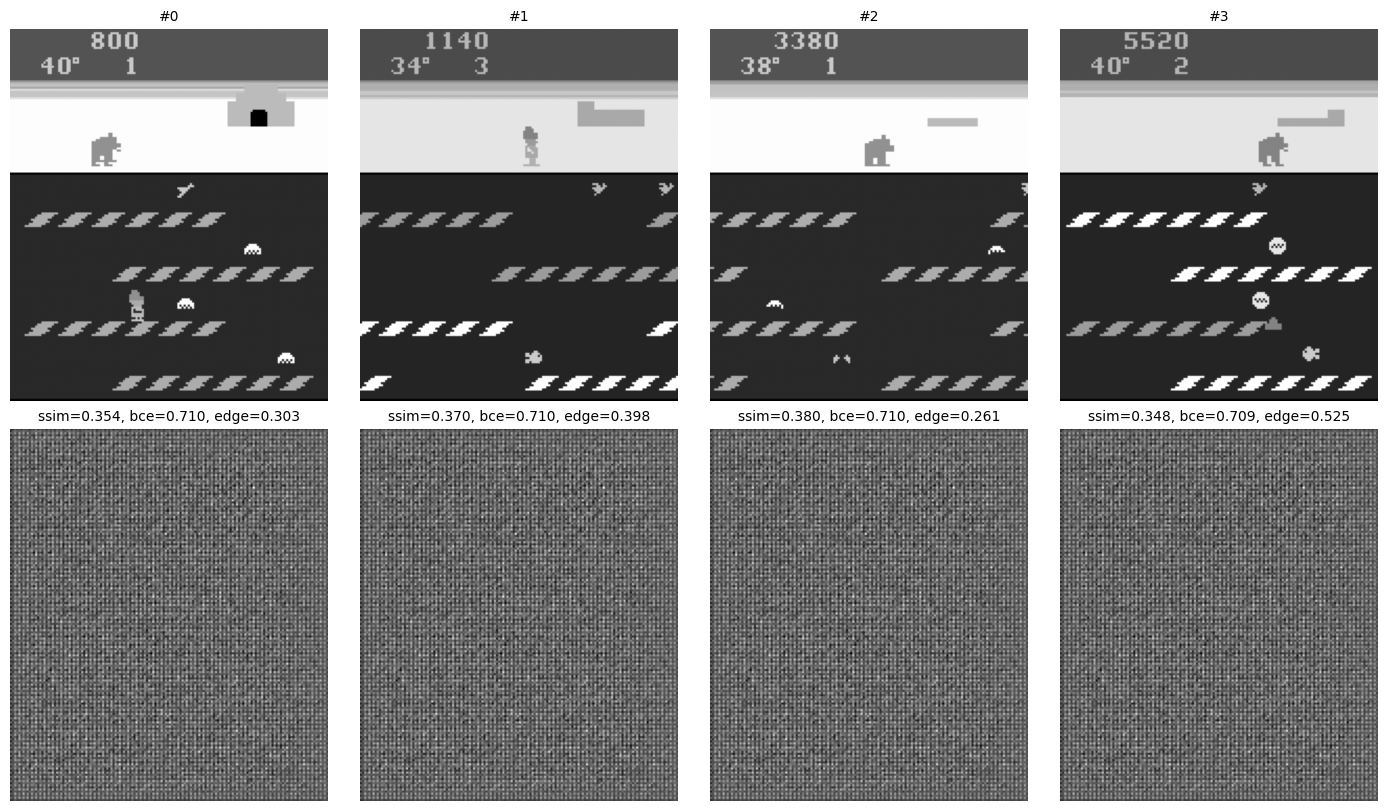

In [43]:
# @launchit.disable
for fig, _ in render_reconstructions(RT.world_model, RT.render_test_batches['recon'], edge_detector=edge_detector):
    break

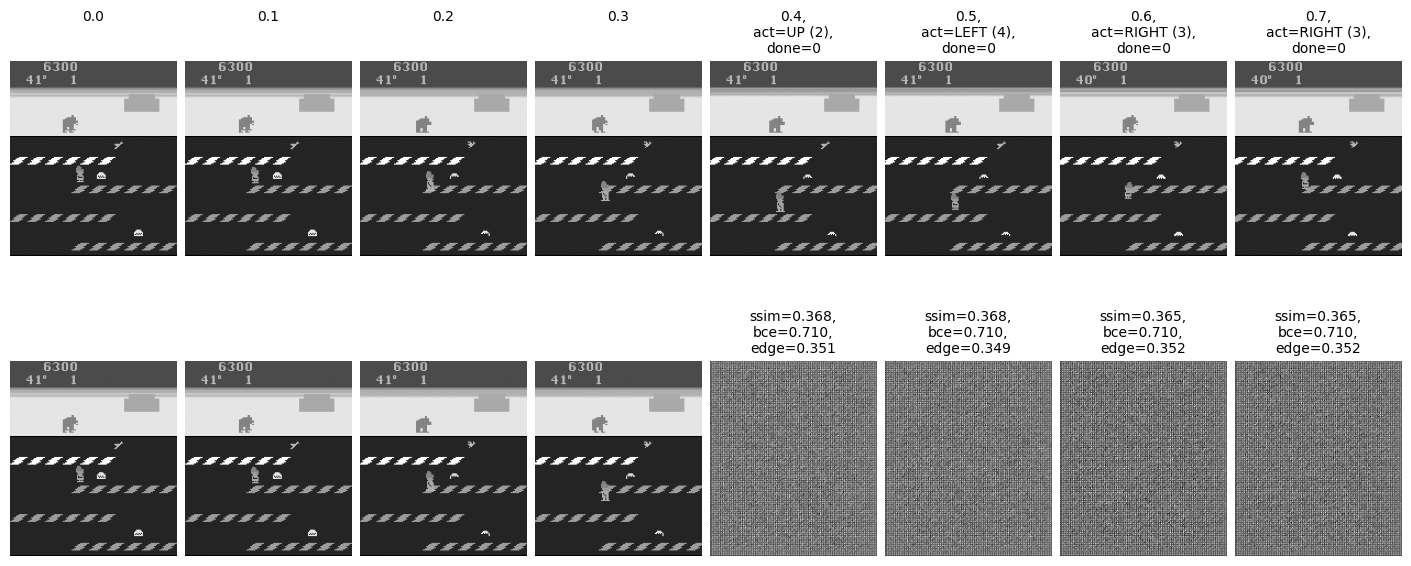

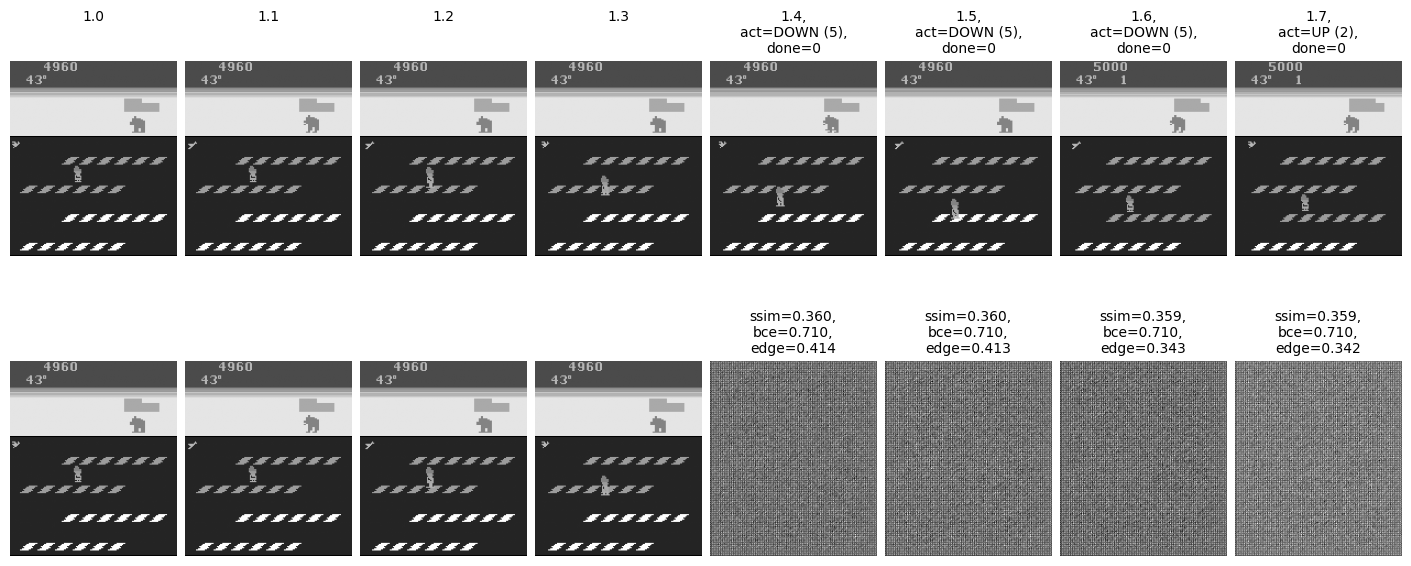

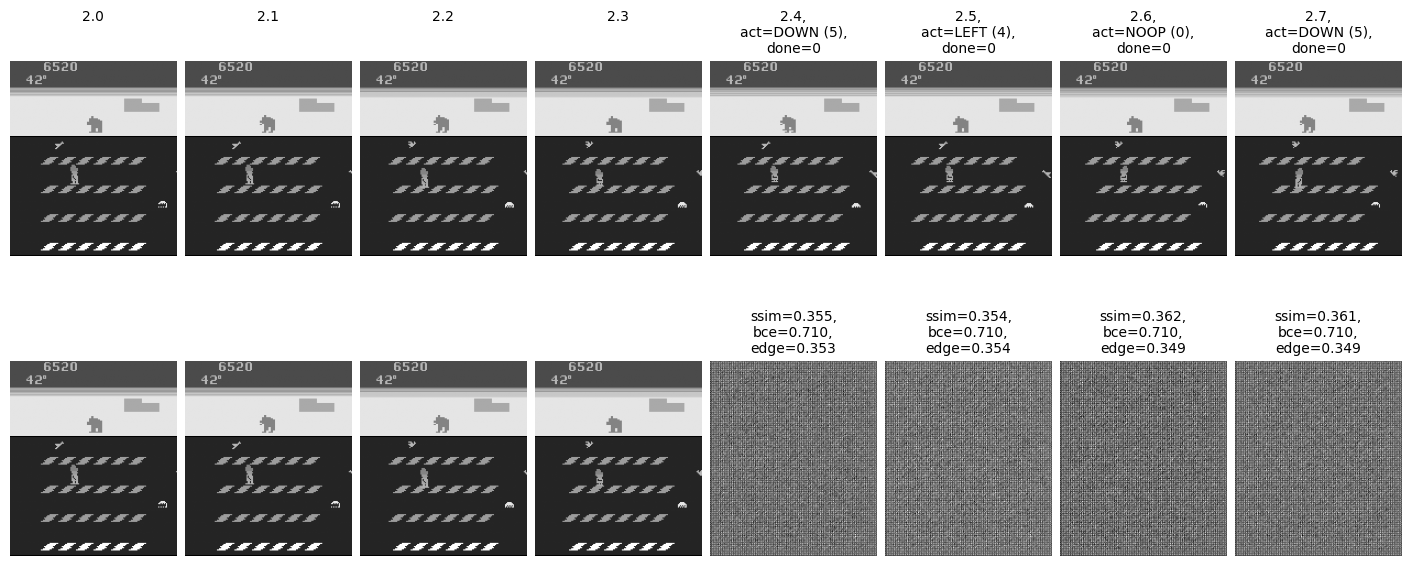

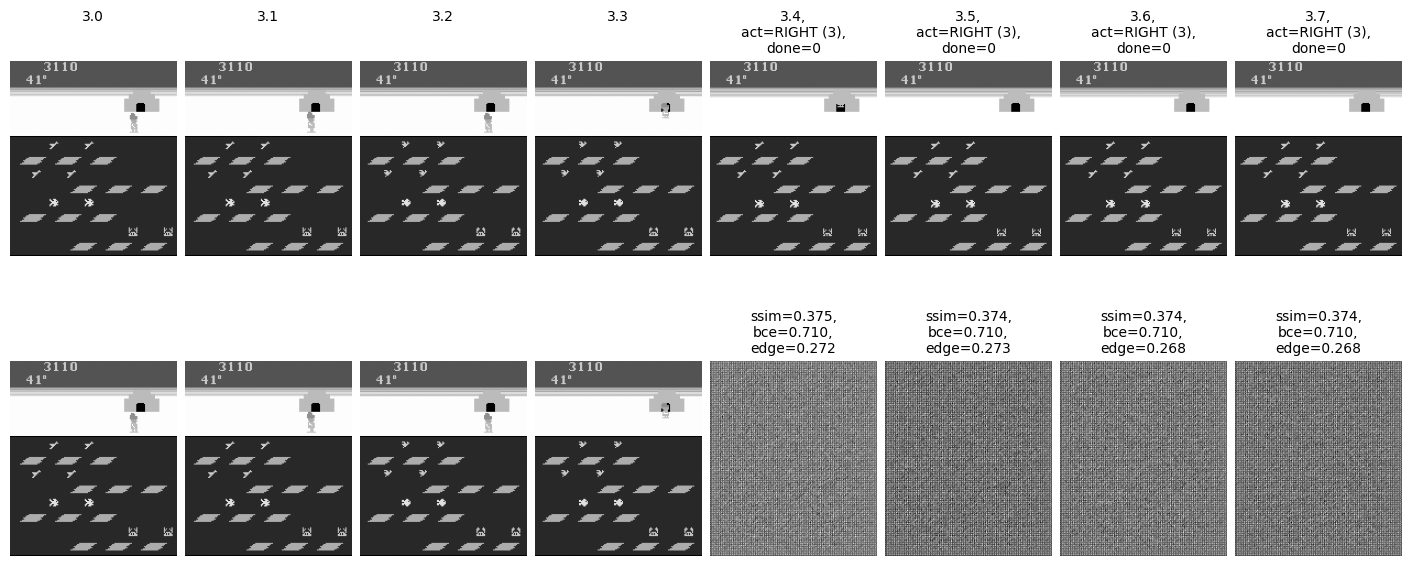

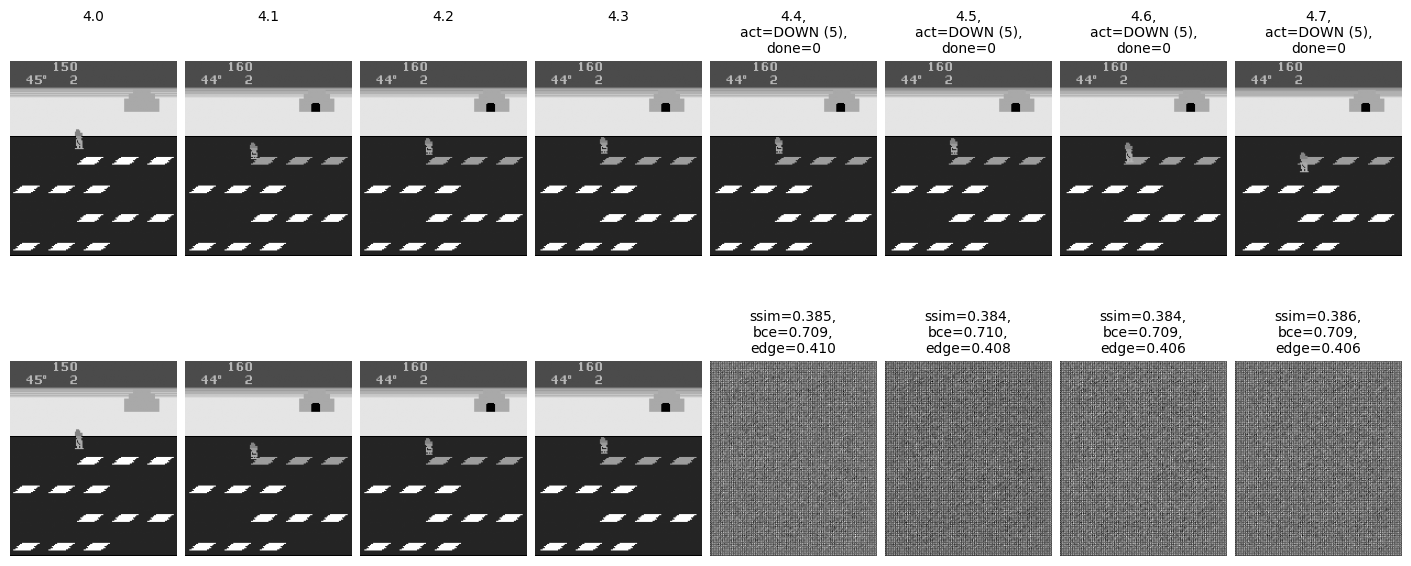

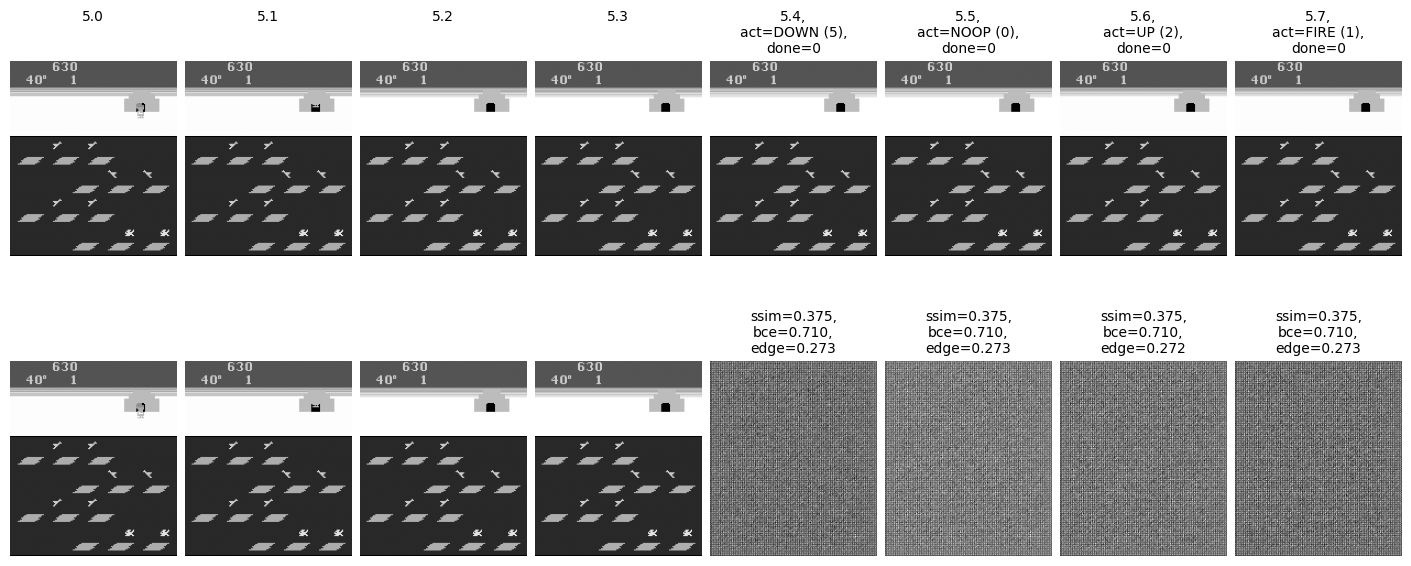

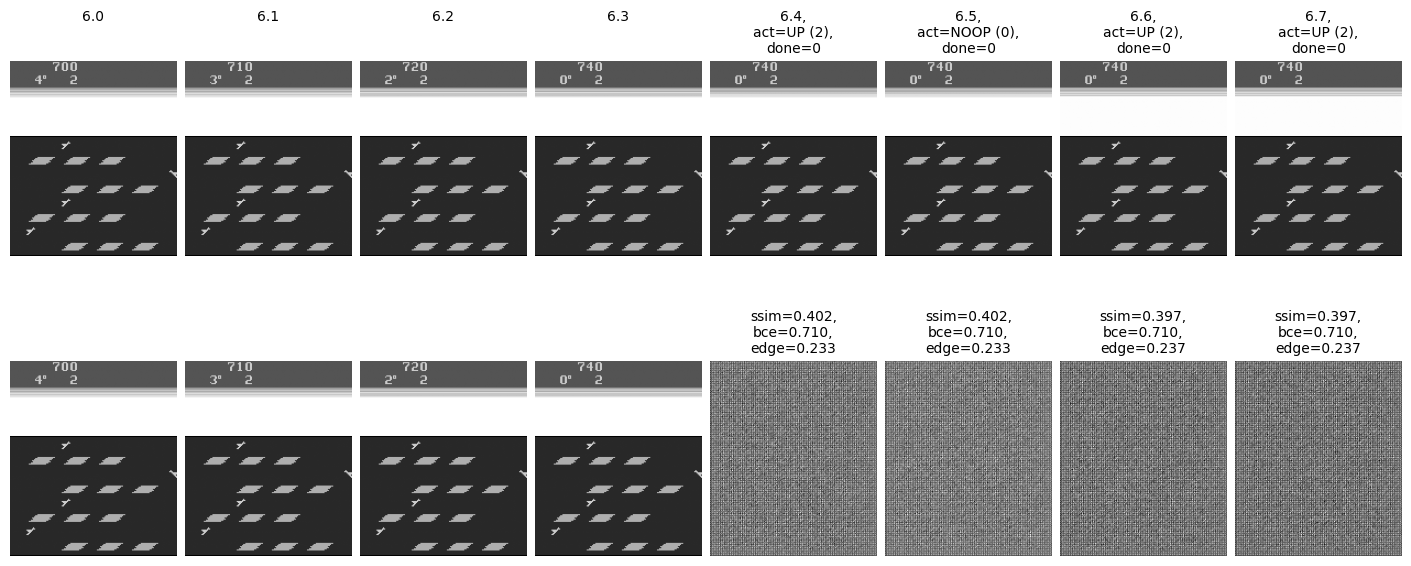

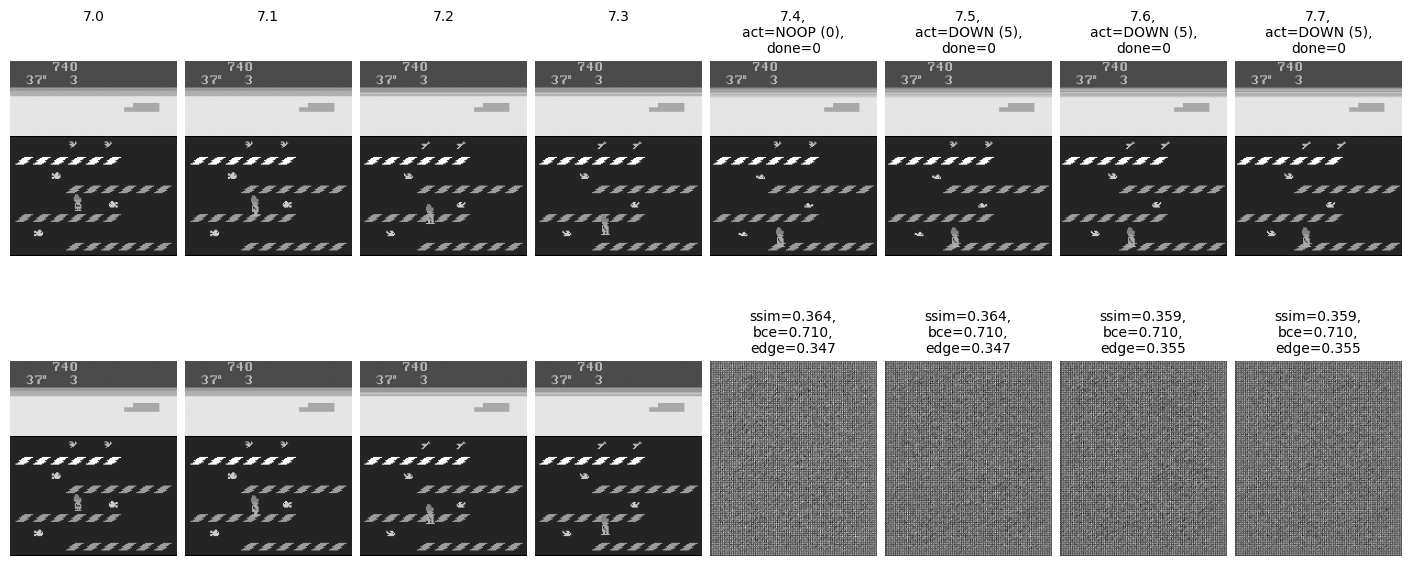

In [44]:
# @launchit.disable
for fig, _ in render_predictions(RT.world_model, RT.render_test_batches['pred'], edge_detector=edge_detector):
    pass

## Train

In [ ]:
metrics_suite = defaultdict(list)
timings = {}
processed_batch_items = 0
test_dataset = load_dataset(RT.test_dataset_fname).clone().to(CONFIG.cuda_device)
test_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=False)

for epoch in tqdm(range(HP.train.epochs_count), desc='Epoch', disable=not CONFIG.is_interactive):
    old_processed_batch_items = processed_batch_items
    timings.clear()
    t0 = time.monotonic()

    # EXECUTE EXTERNAL COMMANDS
    if command := RT.command_listener.get_command():
        LOG(f'Got {command=}')
        
        if command == 'stop':
            RT.should_save_model = True
            break
        elif command == 'abort':
            RT.should_save_model = False
            break
        else:
            LOG(f'Ignoring unknown {command=}')

    # ANNEAL
    progress = epoch / HP.train.epochs_count
    lr = lr_anneal(progress)
    for param_group in optimizer.param_groups: param_group['lr'] = lr
    bce_loss_coef = bce_loss_coef_anneal(progress)
    edge_loss_coef = edge_loss_coef_anneal(progress)
    recon_loss_coef = recon_loss_coef_anneal(progress)
    pred_loss_coef = pred_loss_coef_anneal(progress)

    # OPTIMIZATION
    t1 = time.monotonic()
    train_dataset_id = RNG.choice(list(RT.train_datasets.keys())).item()
    LOG(f'{train_dataset_id=}', when=not CONFIG.is_interactive)
    train_dataset = load_dataset(RT.train_datasets[train_dataset_id])
    train_dataset = train_dataset.clone().to(CONFIG.cuda_device)
    train_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=True)

    RT.world_model.train()
    old_processed_batch_items = processed_batch_items
    
    for batch in tqdm(train_dataset, desc='Train batch', total=train_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
        # Important batch items invariants and conditions are highlighted in "rollout: pmasks, obs, actions, dones"

        if HP.launch_goal in ('train_predictor', 'train_all', None):
            # Need at least one obs for prediction, so filter out batch items which don't have enough items
            batch_mask = batch.pmasks.sum(axis=1) < RT.world_model.params.input_sequence_length
            batch = batch._replace(
                pmasks=batch.pmasks[batch_mask],
                obs=batch.obs[batch_mask],
                actions=batch.actions[batch_mask],
                dones=batch.dones[batch_mask],
            )
            assert len(batch.obs) > 0

        with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.general.is_torch_amp):
            batch_size = len(batch.obs)
            # 3 scenarios:
            # 1) for encoder-only training only last ob in sequence is needed. Last ob is always present
            #   (recon training over all obs in sequence is senseless since they will be just repeated in different items)
            # 2) for predictor-only training with BCE+Edge loss only history obs in sequence are needed
            # 3) for predictor-only training with MSE/InfoNCE loss all obs in sequence are needed
            # 4) for overall training with all obs in sequence are needed
            # Since the goal is to use MSE/InfoNCE and since there is no big win in memory/performance between 2) and 3) vs complication 
            # we stick to just 2) scenarios: 1) and 3)
            if HP.launch_goal == 'train_encoder':
                input_obs = batch.obs[:,-1:] # keep last dim
                assert input_obs.shape[:2] == (batch_size, 1)
            else:
                input_obs = batch.obs

            encode_result = RT.world_model.encoder(RT.world_model.encoder_ob_preprocessor(input_obs))
            assert encode_result.latents.requires_grad == RT.world_model.encoder.is_trainable

            recon_loss, recon_bce_loss, recon_edge_loss = 0, 0, 0

            if HP.launch_goal in ('train_encoder', 'train_all', None):
                assert encode_result.latents.requires_grad
                assert RT.world_model.encoder.is_trainable
                # For encoder training only last ob in sequence does matter
                recon_obs = RT.world_model.renderer(encode_result.latents[:,-1]).logits
                assert recon_obs.shape == (batch_size, *RT.world_model.params.renderer['ob_shape'])
            
                true_obs = RT.world_model.renderer_ob_preprocessor(batch.obs[:,-1])
                assert true_obs.shape == (batch_size, *RT.world_model.params.renderer['ob_shape'])
                
                recon_bce_loss = F.binary_cross_entropy_with_logits(recon_obs, true_obs) # recon_obs contains raw logits, so use BCE with logits!
                recon_edges = edge_detector(torch.sigmoid(recon_obs))
                true_edges = edge_detector(true_obs)
                recon_edge_loss = F.mse_loss(recon_edges.magnitude, true_edges.magnitude)
                
                recon_loss = bce_loss_coef * recon_bce_loss + edge_loss_coef * recon_edge_loss

            pred_loss, pred_bce_loss, pred_edge_loss = 0, 0, 0
            
            if HP.launch_goal in ('train_predictor', 'train_all', None):
                assert RT.world_model.predictor.is_trainable
                # based on history obs predict next ones in sequence
                predict_result = RT.world_model.predictor(
                    latents=encode_result.latents[:,:RT.world_model.params.input_sequence_length], 
                    padding_masks=batch.pmasks[:,:RT.world_model.params.input_sequence_length],
                    actions=batch.actions,
                )
                
                if HP.train.pred_loss['type'] == 'BCE+Edge':
                    pred_obs = RT.world_model.renderer(predict_result.latents).logits
                    assert pred_obs.shape == (batch_size, RT.world_model.params.pred_sequence_length, *RT.world_model.params.renderer['ob_shape'])
                
                    true_obs = RT.world_model.renderer_ob_preprocessor(batch.obs[:,-RT.world_model.params.pred_sequence_length:].clone())
                    assert true_obs.shape == (batch_size, RT.world_model.params.pred_sequence_length, *RT.world_model.params.renderer['ob_shape'])
        
                    pred_bce_loss = F.binary_cross_entropy_with_logits(pred_obs, true_obs) # pred_obs contains raw logits, so use BCE with logits!
                    pred_edges = edge_detector(torch.sigmoid(pred_obs))
                    true_edges = edge_detector(true_obs)
                    pred_edge_loss = F.mse_loss(pred_edges.magnitude, true_edges.magnitude)
                    
                    pred_loss = bce_loss_coef * pred_bce_loss + edge_loss_coef * pred_edge_loss
                elif HP.train.pred_loss['type'] == 'MSE':
                    # https://share.google/aimode/nscIyrYXpPFAzlGMq
                    pred_latents = predict_result.latents
                    assert pred_latents.shape == (batch_size, RT.world_model.params.pred_sequence_length, RT.world_model.params.d_model)
                    
                    true_latents = encode_result.latents[:,-RT.world_model.params.pred_sequence_length:].detach()
                    assert pred_latents.shape == true_latents.shape

                    proj_pred_latents = RT.world_model.struct_projector(pred_latents)
                    proj_true_latents = RT.world_model.struct_projector(true_latents)
                    
                    # Normalize vectors to a unit hypersphere before MSE to ensure scale-invariance
                    norm_proj_pred_latents = F.normalize(proj_pred_latents, dim=-1)
                    norm_proj_true_latents = F.normalize(proj_true_latents, dim=-1)
                    
                    pred_loss = F.mse_loss(norm_proj_pred_latents, norm_proj_true_latents)
                elif HP.train.pred_loss['type'] == 'InfoNCE':
                    # https://share.google/aimode/nscIyrYXpPFAzlGMq
                    pred_latents = predict_result.latents
                    assert pred_latents.shape == (batch_size, RT.world_model.params.pred_sequence_length, RT.world_model.params.d_model)
                    
                    true_latents = encode_result.latents[:,-RT.world_model.params.pred_sequence_length:].detach()
                    assert pred_latents.shape == true_latents.shape

                    @functools.cache
                    def get_info_nce_targets(count):
                        return torch.arange(count, device=CONFIG.cuda_device)

                    # normalize to get dot product == cos sim
                    proj_pred_latents = RT.world_model.struct_projector(pred_latents)
                    proj_true_latents = RT.world_model.struct_projector(true_latents)
                    
                    info_nce_q = F.normalize(proj_pred_latents, dim=-1)
                    info_nce_k = F.normalize(proj_true_latents, dim=-1)
                    info_nce_logits = (info_nce_q @ info_nce_k.T) / HP.train.pred_loss['temperature'] # scaled cos sim 
                    info_nce_targets = get_info_nce_targets(len(info_nce_logits)) # diagonals must match, everything else - pushed away
                    
                    pred_loss = F.cross_entropy(info_nce_logits, info_nce_targets)
                else:
                    assert False, f'Unsupported {HP.train.pred_loss['type']=}'

            # Total composite loss
            loss = recon_loss_coef * recon_loss + pred_loss_coef * pred_loss

        optimizer.zero_grad()
        loss.backward()
        group_grad_norms = calc_group_grad_norms(RT.world_model)
        grad_norm = lu.when(
            HP.train.max_grad_norm is not None,
            lambda: torch.nn.utils.clip_grad_norm_(optimized_params, max_norm=HP.train.max_grad_norm),
            0
        )
        optimizer.step()

        processed_batch_items += batch_size

    LOG(f'Optimization done, {processed_batch_items - old_processed_batch_items:_} batch items processed', when=not CONFIG.is_interactive)
    timings['optimization'] = time.monotonic() - t1

    # FOLLOW-UP optimization (first epoch, last epoch and every 10% of progress)
    if (epoch == 0) or (epoch == HP.train.epochs_count - 1) or (epoch % max(1, (HP.train.epochs_count // 10)) == 0): 
        RT.world_model.eval() # must have, otherwise running means of BatchNorm could be spoiled
            
        with torch.no_grad():
            t1 = time.monotonic()
            recon_ssims_sum, recon_ssims_count = 0, 0
            pred_ssims_sum, pred_ssims_count = 0, 0
            pred_last_ob_ssims_sum, pred_last_ob_ssims_count = 0, 0

            for batch in tqdm(test_dataset, desc='Test batch', total=test_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
                if HP.launch_goal in ('train_predictor', 'train_all', None):
                    # Need at least one obs for prediction, so filter out batch items which don't have enough items
                    batch_mask = batch.pmasks.sum(axis=1) < RT.world_model.params.input_sequence_length
                    batch = batch._replace(
                        pmasks=batch.pmasks[batch_mask],
                        obs=batch.obs[batch_mask],
                        actions=batch.actions[batch_mask],
                        dones=batch.dones[batch_mask],
                    )
                    
                assert len(batch.obs) > 0
                batch_size = len(batch.obs)

                if HP.launch_goal == 'train_encoder':
                    input_obs = batch.obs[:,-1:] # keep last dim
                    assert input_obs.shape[:2] == (batch_size, 1)
                else:
                    input_obs = batch.obs
                
                with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.general.is_torch_amp):
                    encode_result = RT.world_model.encoder(RT.world_model.encoder_ob_preprocessor(input_obs))
                    predict_result = None

                    if HP.launch_goal in ('train_predictor', 'train_all', None):
                        predict_result = RT.world_model.predictor(
                            latents=encode_result.latents[:,:RT.world_model.params.input_sequence_length], 
                            padding_masks=batch.pmasks[:,:RT.world_model.params.input_sequence_length],
                            actions=batch.actions, 
                        )

                #### RECONSTRUCTION
                if HP.launch_goal in ('train_encoder', 'train_all', None):
                    recon_obs = RT.world_model.renderer(encode_result.latents[:,-1]).logits
                    assert recon_obs.shape == (batch_size, *RT.world_model.params.renderer['ob_shape'])
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    recon_obs = recon_obs.float()
                    recon_obs = torch.sigmoid(recon_obs)
                    
                    true_obs = RT.world_model.renderer_ob_preprocessor(batch.obs[:,-1])
                    assert true_obs.shape == (batch_size, *RT.world_model.params.renderer['ob_shape'])
                    
                    ssims = piq.ssim(recon_obs, true_obs, reduction='none')
                    recon_ssims_sum += ssims.sum().item()
                    recon_ssims_count += len(ssims)

                #### PREDICTION
                if HP.launch_goal in ('train_predictor', 'train_all', None):
                    assert predict_result is not None
                    pred_obs = RT.world_model.renderer(predict_result.latents).logits
                    assert pred_obs.shape == (batch_size, RT.world_model.params.pred_sequence_length, *RT.world_model.params.renderer['ob_shape'])
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    pred_obs = pred_obs.float()
                    pred_obs = torch.sigmoid(pred_obs)
                
                    true_obs = RT.world_model.renderer_ob_preprocessor(batch.obs[:,-RT.world_model.params.pred_sequence_length:].clone())
                    assert true_obs.shape == (batch_size, RT.world_model.params.pred_sequence_length, *RT.world_model.params.renderer['ob_shape'])

                    pred_obs = pred_obs.view(-1, *RT.world_model.params.renderer['ob_shape'])
                    true_obs = true_obs.view(-1, *RT.world_model.params.renderer['ob_shape'])
                    ssims = piq.ssim(pred_obs, true_obs, reduction='none')
                    pred_ssims_sum += ssims.sum().item()
                    pred_ssims_count += len(ssims)

            ssim_mean = (recon_ssims_sum + pred_ssims_sum) / (recon_ssims_count + pred_ssims_count)
            RT.summary_writer.add_scalar('test/a) ssim', ssim_mean, epoch)
            metrics_suite['ssim'].append(ssim_mean)
            
            if recon_ssims_count > 0:
                RT.summary_writer.add_scalar('test/c1) recon_ssim', recon_ssims_sum / recon_ssims_count, epoch)

            if pred_ssims_count > 0:
                RT.summary_writer.add_scalar('test/d1) pred_ssim', pred_ssims_sum / pred_ssims_count, epoch)

        LOG(f'test done: ssim={ssim_mean:.4f}', when=not CONFIG.is_interactive)
        timings['test'] = time.monotonic() - t1
        t1 = time.monotonic()

        if HP.launch_goal in ('train_encoder', 'train_all', None):
            for fig_i, (fig, fig_ssim) in enumerate(render_reconstructions(RT.world_model, RT.render_test_batches['recon'], edge_detector=edge_detector)):
                fig_name = f'recon/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) recon_ssim_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_reconstructions done', when=not CONFIG.is_interactive)

        if HP.launch_goal in ('train_predictor', 'train_all', None):
            for fig_i, (fig, fig_ssim) in enumerate(render_predictions(RT.world_model, RT.render_test_batches['pred'], edge_detector=edge_detector)):
                fig_name = f'pred/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) pred_ssim_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_predictions done', when=not CONFIG.is_interactive)
            
        timings['render'] = time.monotonic() - t1        

    # REPORT
    t_end = time.monotonic()
    RT.summary_writer.add_scalar('timings/a) eps', 1 / (t_end - t0), epoch) # epochs per second, bigger = better
    RT.summary_writer.add_scalar('timings/a.2) bips', (processed_batch_items - old_processed_batch_items) / (t_end - t0), epoch) # batch items per second, bigger = better
    RT.summary_writer.add_scalar('timings/b) total', t_end - t0, epoch) # time per whole cycle, lesset = better
    RT.summary_writer.add_scalar('timings/c) optimization', timings['optimization'], epoch) # time per optimization, lesser = better

    if 'test' in timings:
        RT.summary_writer.add_scalar('timings/d) test', timings['test'], epoch) 
    
    if 'render' in timings:
        RT.summary_writer.add_scalar('timings/e) render', timings['render'], epoch) 
    
    RT.summary_writer.add_scalar('anneal/a) learn_rate', lr, epoch)
    RT.summary_writer.add_scalar('anneal/b) bce_loss_coef', bce_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/c) edge_loss_coef', edge_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/d) recon_loss_coef', recon_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/e) pred_loss_coef', pred_loss_coef, epoch)
    
    RT.summary_writer.add_scalar('optimization/a) loss', loss, epoch)
    RT.summary_writer.add_scalar('optimization/d) recon_loss', recon_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d1) recon_bce_loss', recon_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d2) recon_edge_loss', recon_edge_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e) pred_loss', pred_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e1) pred_bce_loss', pred_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e2) pred_edge_loss', pred_edge_loss, epoch)
    
    RT.summary_writer.add_scalar('optimization/z) processed_batch_items', processed_batch_items, epoch)
    
    RT.summary_writer.add_scalar('grad/a) total', grad_norm, epoch)
    
    for name, value in group_grad_norms.items(): 
        RT.summary_writer.add_scalar(f'grad/b) {name}', value, epoch)
        
    RT.summary_writer.flush()

    progress = (epoch + 1) / HP.train.epochs_count
    LOG(f'Progress {100 * progress:.2f}% ({epoch + 1:_} / {HP.train.epochs_count:_})', when=not CONFIG.is_interactive)

## Save

In [ ]:
# @launchit.disable_worker
lc = HP.launch_component()

if lc.version != 0:
    if not RT.should_save_model:
        LOG(f'Model saving skipped')
    else:
        for model_name, model in RT.world_model.models.items():
            with io.BytesIO() as b:
                # Force both compiled and non-compiled models to be saved with the same keys
                state_dict = lu.when(hasattr(model, '_orig_mod'), lambda: model._orig_mod.state_dict(), lambda: model.state_dict())
                torch.save(state_dict, b)
                RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='pt', asset_classifier=model_name, replace=True)

            if hasattr(model, 'params'):
                with io.StringIO() as b:
                    json.dump(dataclasses.asdict(model.params), b)
                    RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier=f'{model_name}_params', replace=True)

            LOG(f'WorldModel.{model_name} saved to artifact registry')
    
        with io.StringIO() as b:
            json.dump(metrics_suite, b)
            RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='metrics_suite', replace=True)
            LOG(f'Metrics suite saved to artifact registry')
    
        with open(CONFIG.metrics_suite_fname, 'w') as f:
            json.dump(metrics_suite, f)
            LOG(f'Metrics suite saved to "{CONFIG.metrics_suite_fname}"')

    if LOG.log_fname is not None and os.path.exists(LOG.log_fname):
        import gzip, shutil
        gzip_fname = LOG.log_fname + '.gz'

        with open(LOG.log_fname, 'rb') as log_file:
            with gzip.open(gzip_fname, 'wb') as gzip_file:
                shutil.copyfileobj(log_file, gzip_file)
        
        RT.summary_writer.add_file(gzip_fname, os.path.basename(gzip_fname))
        RT.summary_writer.flush()
        LOG(f'Log file "{LOG.log_fname}" captured')

# LaunchIt!

## LAUNCH_NOTEBOOK

In [12]:
# @launchit.disable
launchit_t0 = time.monotonic()

In [244]:
# @launchit.disable
launchit_interval = time.monotonic() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=[], 
        disable_inds=[]
    )
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=112
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_07-launch112.ipynb
Created launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_07-launch112.ipynb"


## DOCKER_LAUNCH_NOTEBOOK

In [159]:
# @launchit.disable
launchit_t0 = time.monotonic()

In [160]:
# @launchit.collect_manual_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import launch_dispatcher
    image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
    launch_request = dict(
        launch_image=image_tag,
        keep_container=False,
    )
    launch_dispatcher.LaunchRequest.run(launch_request)
# @launchit.stop

In [224]:
# @launchit.disable
launchit_interval = time.monotonic() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=['initrd', 'build_docker_launch', 'manual_run_docker_launch', 'temp_config'], 
        disable_inds=[]
    )
    LOG(f'Created docker launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=72
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_08-launch72.ipynb
Created docker launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_08-launch72.ipynb"


# System

## Optuna outside DOCKER_LAUNCH

In [ ]:
# @launchit.collect_optuna
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK and os.path.exists('${OPTUNA_STUDY_FNAME}'):
    import re
    import launchit
    optuna_study_fname = '${OPTUNA_STUDY_FNAME}'
    optuna_study_storage = JournalStorage(JournalFileBackend(optuna_study_fname))
    optuna_study_name = '${OPTUNA_STUDY_NAME}'
    assert optuna_study_name
    assert optuna_study_name != '$' + '{OPTUNA_STUDY_NAME}', optuna_study_name
    
    optuna_study_nb_fname = re.sub('.optuna$', '.ipynb', optuna_study_fname)
    source_code = launchit.extract_source_code(optuna_study_nb_fname)
    Logging.get()(f'Extracted source code for set_hyperparamters from "{optuna_study_nb_fname}"')
    module = lu.make_module('optuna_study_hyperparameters', source_code)
    grid_search_space = lu.when(hasattr(module, 'GRID_SEARCH_SPACE'), lambda: module.GRID_SEARCH_SPACE, None)
    
    optuna_study = optuna.load_study(
        study_name=optuna_study_name, 
        storage=optuna_study_storage,
        sampler=lu.when(grid_search_space, lambda: optuna.samplers.GridSampler(grid_search_space), None)
    )
    
    optuna_trial = optuna_study.ask()
    optuna_trial.set_user_attr('MODEL_VERSION', '${MODEL_VERSION}')
    optuna_study_serial = optuna_study.user_attrs['STUDY_SERIAL']
    
    HP = module.set_hyperparameters(Hyperparameters(), optuna_study, optuna_trial)
    Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')

    assert os.path.exists(CONFIG.initrd_path)

    with open(os.path.join(CONFIG.initrd_path, 'optuna_trial.json'), 'w') as f:
        optuna_trial_dict = dict(
            trial_number=optuna_trial.number,
            study_serial=optuna_study_serial,
            study_name=optuna_study_name,
        )
        json.dump(optuna_trial_dict, f)

    with open(os.path.join(CONFIG.initrd_path, 'hyperparameters.json'), 'w') as f:
        json.dump(HP._asdict(), f)
        
elif CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK:
    hyperparameters_fname = os.path.join(CONFIG.initrd_path, 'hyperparameters.json')
    
    with open(hyperparameters_fname, 'r') as f:
        HP = Hyperparameters.from_dict(json.load(f))
        Logging.get()(f'HP loaded from "{hyperparameters_fname}"')
        Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')


## Optuna within DOCKER_LAUNCH

In [228]:
# @launchit.collect_optuna_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    # optuna_study and optuna_trial are created in cell above
    assert optuna_study is not None
    assert optuna_trial is not None

    import launch_dispatcher
    short_image_tag = '${MODEL_NAME}' + ':' + '${MODEL_VERSION}'
    image_tag = os.path.join(CONFIG.docker_registry, short_image_tag)
    launch_request = dict(
        launch_image=image_tag,
        result_fname=os.path.join(project_root_path, CONFIG.relative_metrics_suite_fname),
        keep_container=False,
    )
    launch_result_metadata, launch_result_body = launch_dispatcher.LaunchRequest.run(launch_request)
    
    with open(CONFIG.self_fname + '.out', mode='wt') as out_file:
        if launch_result_metadata['is_ok']:
            if launch_result_body:
                decisive_metric = 'ssim'
                
                with io.BytesIO(launch_result_body) as b:
                    launch_result_dict = json.load(b)
    
                if launch_result_dict.get(decisive_metric, []):
                    scalar_result = launch_result_dict[decisive_metric][-1]
                    optuna_study.tell(optuna_trial, scalar_result, state=optuna.trial.TrialState.COMPLETE)
    
                    message = f'Trial {optuna_trial.number} ({short_image_tag}) finished with value: {scalar_result} and parameters: {optuna_trial.params}'
                    
                    try:
                        best_trial = optuna_study._get_best_trial(deepcopy=False)
                        message += f'. Best is trial {best_trial.number} with value: {best_trial.value}'
                    except ValueError:
                        # If no feasible trials are completed yet, study.best_trial raises ValueError
                        pass

                    out_file.write(message)
                else:
                    optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                    out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty/missing "{decisive_metric}"')
            else:
                optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty result body: {launch_result_metadata=}')
        else:
            optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
            out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) failed: {launch_result_metadata=}')

    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, message="To exit: use 'exit'")
    sys.exit(0)

## Save artifact registry cache

In [ ]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig':
    if CONFIG.artifact_registry_cache:
        with open(CONFIG.artifact_registry_cache_fname, 'wb') as f:
            pickle.dump(CONFIG.artifact_registry_cache, f)

        Logging.get()(f'Artifact registry cache saved to "{CONFIG.artifact_registry_cache_fname}"')
    else:
        Logging.get()(f'Artifact registry cache is empty, nothing to save')
# @launchit.stop

## Docker build

In [ ]:
# @launchit.collect_build_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import subprocess
    import tempfile

    assert os.path.exists(os.path.join(build_project_root_path, CONFIG.relative_self_fname))

    dockerfile_content = f'''
FROM {os.path.join(CONFIG.docker_registry, '18x_data:latest')}
USER 1000
WORKDIR /neurolab
RUN --mount=type=secret,id=neurolab_deploy_key,target=/tmp/neurolab_deploy_key,uid=1000 \\ 
    export GIT_SSH_COMMAND="ssh -i /tmp/neurolab_deploy_key -o IdentitiesOnly=yes" && \\
    git pull --rebase
WORKDIR /neurolab/{CONFIG.subproject_name}
COPY --chown=1000:1000 {CONFIG.relative_self_fname} .
'''
    if os.path.exists(CONFIG.initrd_path):
        dockerfile_content += f'''
RUN mkdir -p /neurolab/{CONFIG.relative_initrd_path}
COPY --chown=1000:1000  {CONFIG.relative_initrd_path} /neurolab/{CONFIG.relative_initrd_path}
'''

    dockerfile_content += f'''
RUN touch /neurolab/.docker_launch
CMD ["papermill", "{os.path.basename(CONFIG.self_fname)}", "{os.path.basename(CONFIG.self_fname)}"]
    '''
    with tempfile.NamedTemporaryFile(mode='wt', suffix='.Dockerfile') as dockerfile:
        with open(dockerfile.name, 'w') as f:
            f.write(dockerfile_content)

        image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
        subprocess.run(
            [
                'docker', 'buildx', 'build', '-f', dockerfile.name, '-t', image_tag, build_project_root_path, 
                '--load', '--no-cache', '--network=host', 
                # --add-host is used to overcome problems with VPN (when VPN enabled build process cannot resolve nexus host)
                '--add-host', 'nexus=127.0.0.1',
                # use SSH to connect to GIT to overcome Anti-DDOS barriers
                '--secret', 'id=neurolab_deploy_key,src=/home/misha/.ssh/neurolab_deploy_key',
            ],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
        subprocess.run(
            ['docker', 'push', image_tag],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
# @launchit.stop